# 0. Problem Understanding

Pada kompetisi ini, peserta diminta melakukan analisis komprehensif terhadap dataset FMCG kategori *Personal Care* yang mencakup data transaksi, aktivitas pemasaran, ulasan pelanggan, dan informasi produk selama periode 2020–2025. Tujuan utama dari analisis ini bukan hanya membangun model prediksi, tetapi juga memahami dinamika bisnis secara menyeluruh dan menghasilkan insight yang dapat digunakan untuk pengambilan keputusan strategis.

Secara garis besar, permasalahan yang ingin dijawab adalah sebagai berikut:

### 1. Bagaimana tren penjualan produk personal care berkembang dari waktu ke waktu?
Analisis ini mencakup identifikasi pola musiman, periode puncak penjualan, penurunan penjualan, serta perbedaan perilaku antar produk atau kategori.

### 2. Faktor apa saja yang memengaruhi kinerja penjualan?
Variabel yang dianalisis meliputi:
- Harga, diskon, dan strategi pricing lain
- Biaya marketing dan engagement rate
- Variasi penjualan per region dan per channel
- Rating dan sentimen ulasan pelanggan
- Siklus hidup produk (days since launch)

### 3. Apakah terdapat potensi cannibalization antar produk?
Produk dengan kategori atau fungsi serupa berpotensi saling memengaruhi performa satu sama lain. Identifikasi cannibalization penting untuk strategi portofolio produk.

### 4. Bagaimana membangun innovation radar berdasarkan data?
Innovation radar bertujuan untuk:
- Mengidentifikasi produk dengan pertumbuhan cepat
- Menemukan kategori yang stagnan atau menurun
- Menilai potensi ekspansi kategori
- Menentukan variabel yang paling signifikan mendorong revenue

### 5. Bagaimana memproyeksikan revenue ke depannya?
Kompetisi meminta peserta untuk membangun model forecasting menggunakan pendekatan machine learning maupun time series modeling untuk mendukung rencana bisnis jangka pendek.

---

## Dataset yang Digunakan

Analisis dilakukan menggunakan beberapa tabel data:

- **products.csv**  
  Informasi master produk, brand, ukuran, harga dasar, dan tanggal peluncuran.

- **sales.csv**  
  Transaksi penjualan harian per produk dan per region.

- **marketing.csv**  
  Informasi kampanye pemasaran, pengeluaran, channel, dan engagement rate.

- **reviews.csv**  
  Ulasan pelanggan, rating, sentimen, dan tanggal ulasan.

---

## Pendekatan Analisis

Pendekatan yang digunakan dalam notebook ini mencakup:

1. **Exploratory Data Analysis (EDA)**  
   Untuk memahami struktur data, distribusi, pola penjualan, dan hubungan antar variabel.

2. **Data Cleaning & Preprocessing**  
   Mengatasi missing values, inkonsistensi data, parsing tanggal, dan penggabungan tabel.

3. **Feature Engineering**  
   Membuat variabel baru seperti total spend, engagement metrics, sentiment encoding, hingga product lifecycle.

4. **Natural Language Processing (NLP)**  
   Ekstraksi fitur dari ulasan pelanggan menggunakan TF-IDF, LSA, LDA, dan Sentence-BERT.

5. **Predictive Modeling (Regression)**  
   Membangun model Random Forest, XGBoost, dan LightGBM untuk memprediksi total revenue.

6. **Time Series Forecasting**  
   Menggunakan ARIMA dan XGBoost autoregressive untuk memprediksi revenue 90 hari ke depan.

7. **Statistical Analysis (OLS & Classical Assumptions)**  
   Untuk memahami signifikansi variabel dan validitas hubungan linear.

8. **Business Insight**  
   Menghasilkan kesimpulan terkait tren, potensi inovasi, dan rekomendasi berdasarkan hasil analisis.

# 1. Import Library

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re, string, gc, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

!pip install sentence-transformers prophet pmdarima optuna --quiet

from sentence_transformers import SentenceTransformer
from prophet import Prophet
from pmdarima import auto_arima
import optuna

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2. Load Dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive/fmcg_dataset

DATA_DIR = "/content/drive/MyDrive/fmcg_dataset/"

# Load dataset dengan parse_dates
products = pd.read_csv(DATA_DIR + "products.csv",parse_dates=["launch_date"])
sales = pd.read_csv(DATA_DIR + "sales.csv",parse_dates=["date"])
marketing = pd.read_csv(DATA_DIR + "marketing.csv",parse_dates=["start_date", "end_date"])
reviews   = pd.read_csv(DATA_DIR + "reviews.csv",parse_dates=["date"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
marketing.csv  README_FMCG_Personal_Care.txt  sales.csv
products.csv   reviews.csv


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami struktur, pola, serta karakteristik utama dari data penjualan, marketing, review, dan produk pada kategori FMCG *Personal Care*. Tahapan ini penting untuk memvalidasi kualitas data, menemukan potensi masalah, serta menyiapkan arah feature engineering dan pemodelan.


## 3.1 Data Overview

Analisis dimulai dengan melihat jumlah baris, kolom, serta tipe variabel dari setiap tabel:
- **products.csv**: Informasi master produk (brand, type, size, launch_date).
- **sales.csv**: Data transaksi harian per produk, region, dan channel.
- **marketing.csv**: Informasi kampanye (spend, channel, engagement_rate).
- **reviews.csv**: Ulasan pelanggan termasuk rating, sentiment, dan teks komentar.

Tujuan dari tahap ini adalah memastikan tidak terdapat inkonsistensi tipe data, khususnya kolom tanggal dan numerik, serta memahami cakupan data dari tahun 2020 hingga 2025.


In [10]:
print("\n=== BASIC INFO: PRODUCTS ===")
print(products.head())
print(products.info())
print(products.describe(include="all"))


=== BASIC INFO: PRODUCTS ===
  product_id                           product_name     brand         type  \
0      PC001   Sunsilk Smooth & Shine Shampoo 340ml   Sunsilk      Shampoo   
1      PC002  Sunsilk Black Shine Conditioner 340ml   Sunsilk  Conditioner   
2      PC003       Lifebuoy Total10 Body Wash 400ml  Lifebuoy    Body Wash   
3      PC004      Lifebuoy Mild Care Handwash 200ml  Lifebuoy     Handwash   
4      PC005        Dove Deep Moisture Lotion 200ml      Dove       Lotion   

   size_ml  base_price launch_date  
0      340       32000  2020-02-15  
1      340       33000  2020-06-10  
2      400       28000  2020-03-20  
3      200       25000  2021-05-01  
4      200       35000  2021-11-12  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    15 non-null     object        
 1   product_name  15 non-n

In [11]:
print("\n=== BASIC INFO: SALES ===")
print(sales.head())
print(sales.info())
print(sales.describe())


=== BASIC INFO: SALES ===
                         transaction_id       date product_id     region  \
0  fa43024c-7c61-4e2b-bfd1-84915e86c4f7 2024-02-04      PC001   Semarang   
1  cc02b941-61b7-4e37-b385-ecfc2fe2a0b0 2022-05-31      PC004      Medan   
2  378b66ac-8b18-43e3-8b91-cfbb0ee1d346 2020-10-24      PC013  Palembang   
3  42ff9d7e-aba8-4444-b144-3ed288c3ae2c 2023-05-31      PC001      Medan   
4  605dfc68-c347-406e-b6af-2bb43cabc515 2024-05-06      PC009      Medan   

     channel  units_sold  avg_price  discount_pct    revenue  \
0     Shopee           4   31721.61             5  126886.45   
1  Tokopedia           4   23148.20             0   92592.80   
2   Alfamart           5   25396.69            20  126983.43   
3  Tokopedia           7   30006.83             0  210047.84   
4  Tokopedia           2   30927.25             5   61854.50   

   days_since_launch  
0               1450  
1                395  
2              -1178  
3               1201  
4               

In [12]:
print("\n=== BASIC INFO: MARKETING ===")
print(marketing.head())
print(marketing.info())
print(marketing.describe(include="all"))


=== BASIC INFO: MARKETING ===
  campaign_id product_id     campaign_name start_date   end_date   spend_idr  \
0      MKT001      PC010  Campaign_1_PC010 2020-10-12 2020-12-14   256411579   
1      MKT002      PC008  Campaign_2_PC008 2020-06-30 2020-08-29   582461991   
2      MKT003      PC006  Campaign_3_PC006 2021-09-01 2021-09-22   884233026   
3      MKT004      PC015  Campaign_4_PC015 2025-04-23 2025-07-04  1139498941   
4      MKT005      PC003  Campaign_5_PC003 2021-07-15 2021-09-08   340924224   

      channel  engagement_rate  
0          TV            0.566  
1          TV            0.376  
2          TV            0.117  
3  Influencer            0.560  
4   Billboard            0.091  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   campaign_id      20 non-null     object        
 1   product_id       20 non-

In [13]:
print("\n=== BASIC INFO: REVIEWS ===")
print(reviews.head())
print(reviews.info())
print(reviews.describe(include="all"))


=== BASIC INFO: REVIEWS ===
  review_id product_id       date  rating sentiment   platform  \
0   R100000      PC014 2024-10-16     4.6  Positive  Instagram   
1   R100001      PC012 2023-06-27     2.8  Negative  Instagram   
2   R100002      PC003 2022-10-21     3.2   Neutral     Shopee   
3   R100003      PC010 2025-03-07     2.0  Negative  Tokopedia   
4   R100004      PC015 2022-03-03     1.5  Negative     Shopee   

                                        comment  
0   Packaging bocor saat diterima, kurang aman.  
1     Mudah dibeli saat promo, value for money.  
2     Mudah dibeli saat promo, value for money.  
3     Mudah dibeli saat promo, value for money.  
4  Memberikan hasil sesuai klaim after 2 weeks.  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   review_id   10000 non-null  object        
 1   product_id  10000 

## 3.2. Missing Values & Data Quality Check

Pada tahap ini dianalisis:
- jumlah missing value per kolom,
- nilai ekstrem atau tidak logis,
- duplikasi,
- inkonsistensi antar tabel setelah penggabungan.

Hal ini penting untuk menentukan strategi *cleaning* seperti imputasi, penghapusan, atau konversi nilai.

In [14]:
# Missing values check
def missing_summary(df, name):
    print(f"\n=== MISSING VALUE SUMMARY: {name} ===")
    print(df.isna().sum().sort_values(ascending=False))

missing_summary(products, "products")
missing_summary(sales, "sales")
missing_summary(marketing, "marketing")
missing_summary(reviews, "reviews")


=== MISSING VALUE SUMMARY: products ===
product_id      0
product_name    0
brand           0
type            0
size_ml         0
base_price      0
launch_date     0
dtype: int64

=== MISSING VALUE SUMMARY: sales ===
transaction_id       0
date                 0
product_id           0
region               0
channel              0
units_sold           0
avg_price            0
discount_pct         0
revenue              0
days_since_launch    0
dtype: int64

=== MISSING VALUE SUMMARY: marketing ===
campaign_id        0
product_id         0
campaign_name      0
start_date         0
end_date           0
spend_idr          0
channel            0
engagement_rate    0
dtype: int64

=== MISSING VALUE SUMMARY: reviews ===
review_id     0
product_id    0
date          0
rating        0
sentiment     0
platform      0
comment       0
dtype: int64


In [15]:
# Unique counts for categorical columns
def cat_summary(df, cat_cols, name):
    print(f"\n=== CATEGORICAL SUMMARY: {name} ===")
    for c in cat_cols:
        print(f"\nColumn: {c}")
        print(df[c].value_counts().head(20))

cat_summary(products, ["brand", "type"], "products")
cat_summary(sales, ["product_id", "region", "channel"], "sales")
cat_summary(marketing, ["product_id", "channel"], "marketing")
cat_summary(reviews, ["product_id", "sentiment", "platform"], "reviews")


=== CATEGORICAL SUMMARY: products ===

Column: brand
brand
Sunsilk                 3
Lifebuoy                3
Dove                    3
Rexona                  2
Clear                   1
Love Beauty & Planet    1
Ponds                   1
Vaseline                1
Name: count, dtype: int64

Column: type
type
Shampoo        5
Body Wash      2
Deodorant      2
Lotion         2
Handwash       1
Conditioner    1
Facial Foam    1
Sanitizer      1
Name: count, dtype: int64

=== CATEGORICAL SUMMARY: sales ===

Column: product_id
product_id
PC005    66972
PC003    66943
PC002    66857
PC004    66823
PC001    66804
PC013    66744
PC006    66689
PC015    66580
PC007    66578
PC012    66576
PC010    66545
PC011    66512
PC009    66476
PC008    66453
PC014    66448
Name: count, dtype: int64

Column: region
region
Medan         100313
Palembang     100078
Semarang      100056
Denpasar      100046
Yogyakarta    100023
Surabaya       99989
Jakarta        99908
Bali           99889
Makassar       9

## 3.3. Descriptive Statistics

Statistik deskriptif digunakan untuk melihat gambaran dasar dari variabel numerik:
- rata-rata revenue harian,
- variasi jumlah unit terjual,
- distribusi harga dan diskon,
- variasi rating pelanggan.

Hasil ini memberikan pemahaman awal terkait sebaran dan potensi outlier.

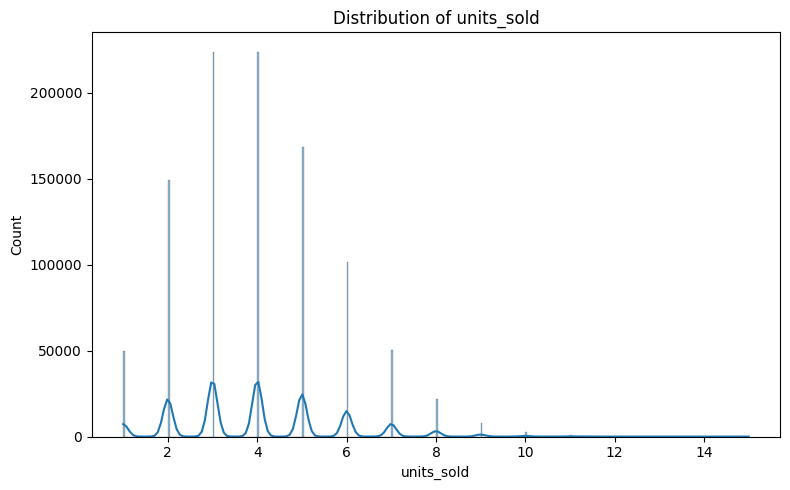

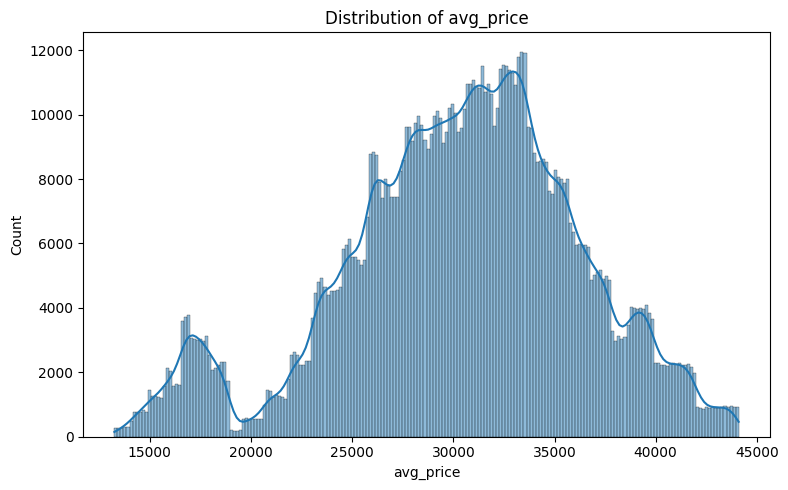

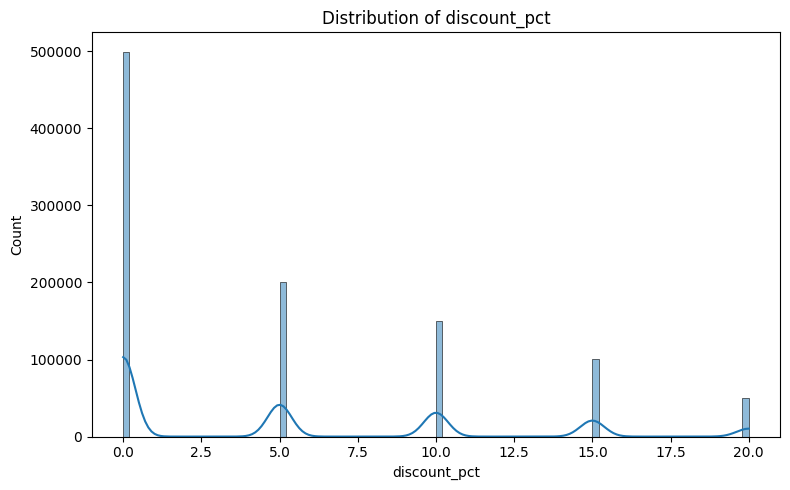

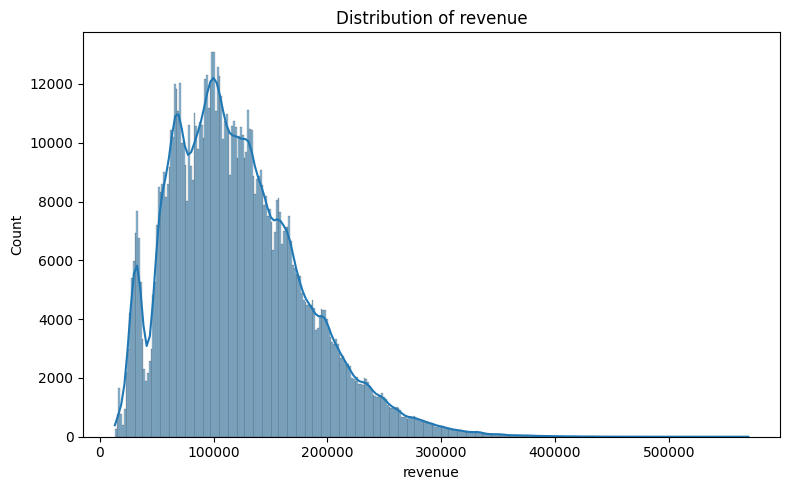

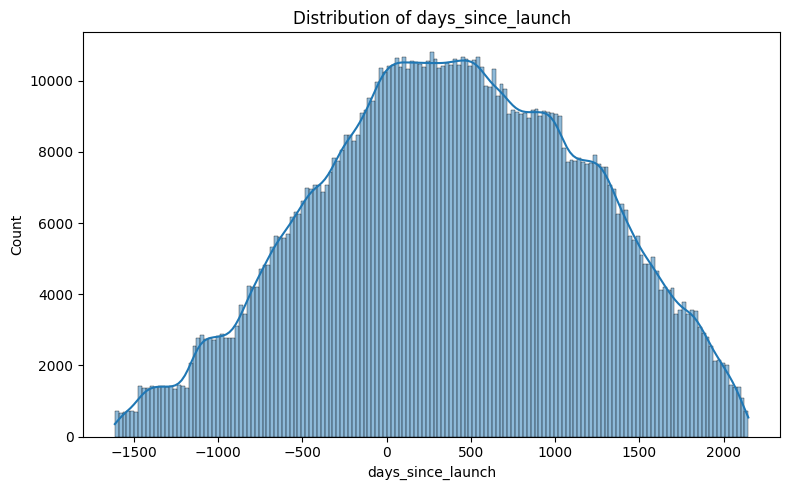

In [16]:
# Distribusi numeric utama di sales
numeric_cols_sales = ["units_sold", "avg_price", "discount_pct", "revenue", "days_since_launch"]

for col in numeric_cols_sales:
    plt.figure(figsize=(8, 5))
    sns.histplot(sales[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


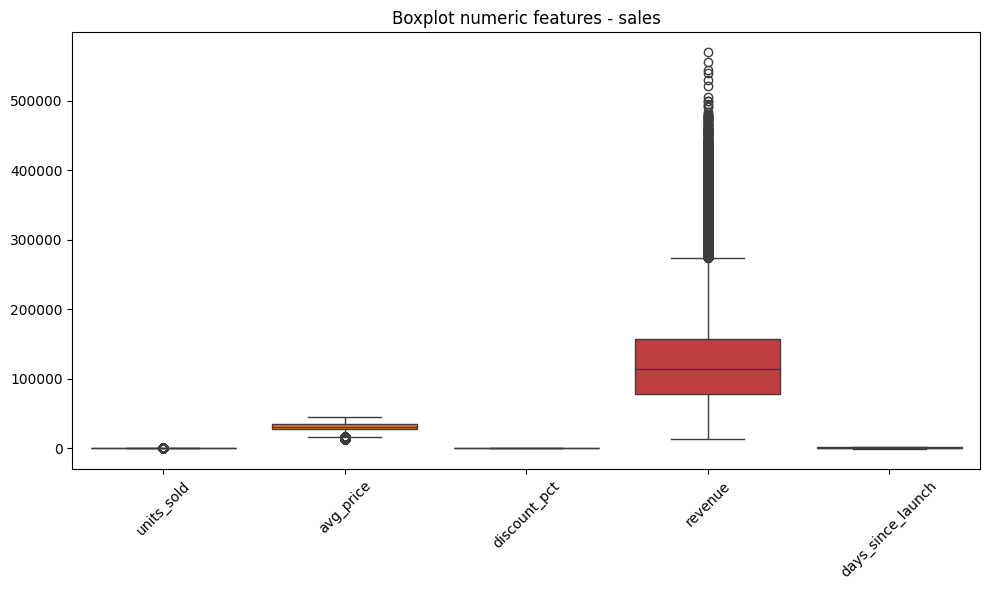

In [17]:
# Boxplot untuk cek outlier
plt.figure(figsize=(10, 6))
sns.boxplot(data=sales[numeric_cols_sales])
plt.title("Boxplot numeric features - sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.4. Time Series Pattern (Daily Sales & Revenue)

Karena bisnis FMCG sangat dipengaruhi pola waktu, dilakukan analisis:
- tren penjualan tahunan (2020–2025),
- pola musiman (bulanan/mingguan),
- fluktuasi harian,
- identifikasi periode puncak (peak season),
- perbandingan antar produk.

Visualisasi diperlukan untuk memahami stabilitas dan dinamika revenue sepanjang periode analisis.

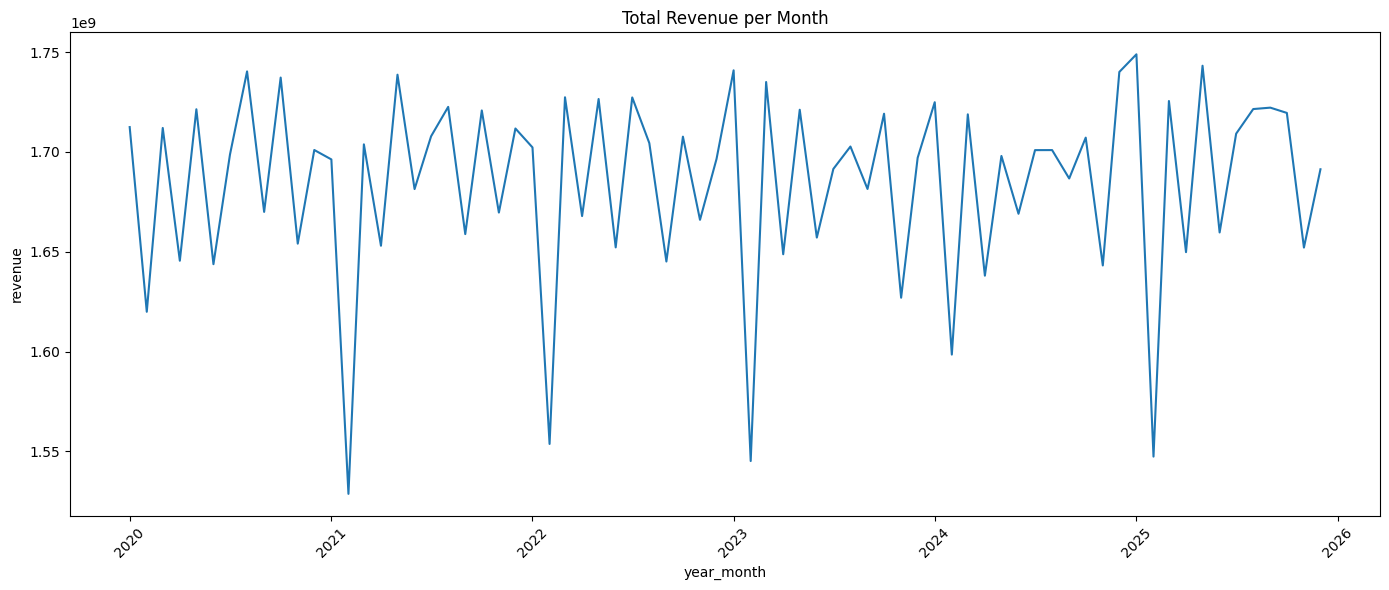

In [18]:
# Time series: total revenue per month
sales["year_month"] = sales["date"].dt.to_period("M").dt.to_timestamp()
monthly_rev = sales.groupby("year_month")["revenue"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_rev, x="year_month", y="revenue")
plt.title("Total Revenue per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3.5. Produk Terlaris dan Paling Sering Dibeli

Analisis agregasi dilakukan untuk mengidentifikasi:
- produk dengan unit terjual tertinggi,
- kontribusi revenue per produk,
- brand yang paling dominan,
- lifecycle produk sejak tanggal peluncuran.

Bagian ini penting untuk menyusun innovation radar di bagian selanjutnya.


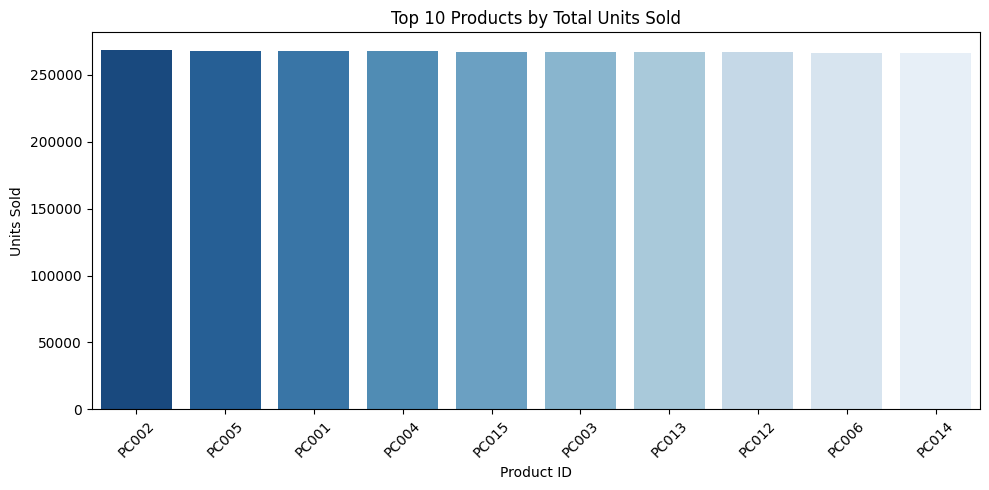

In [19]:
top_units = (
    sales.groupby("product_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_units.index, y=top_units.values, palette="Blues_r")
plt.title("Top 10 Products by Total Units Sold")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


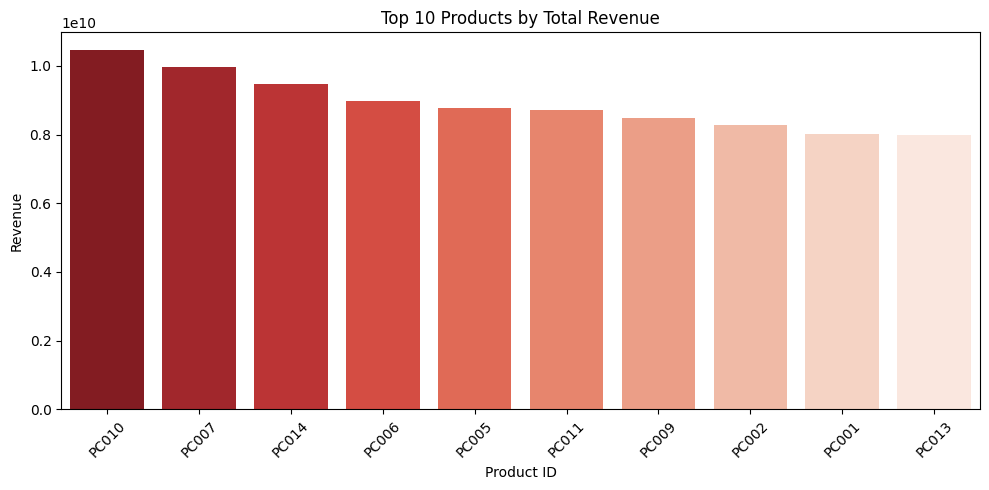

In [20]:
top_revenue = (
    sales.groupby("product_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_revenue.index, y=top_revenue.values, palette="Reds_r")
plt.title("Top 10 Products by Total Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


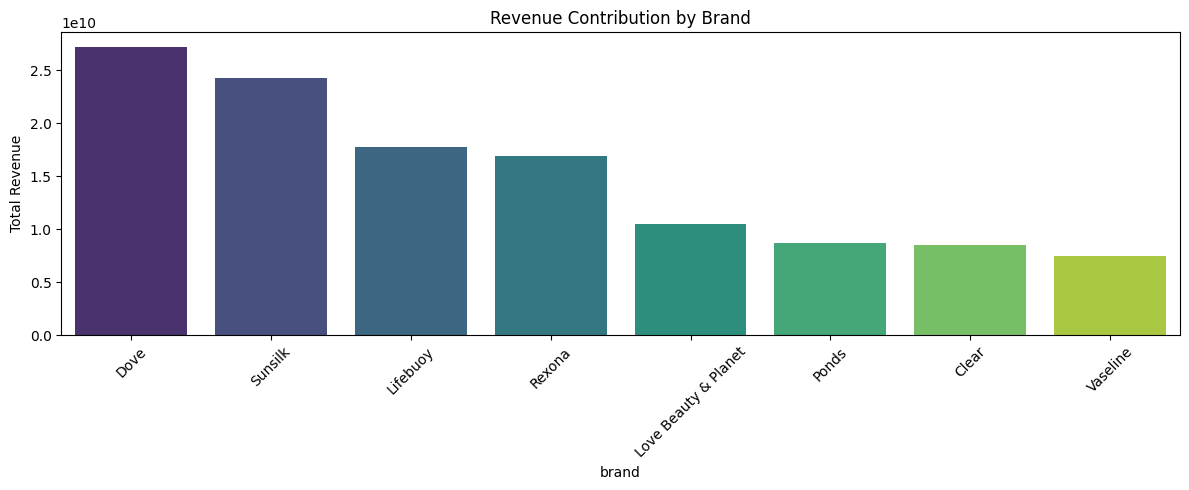

In [21]:
sales_products = sales.merge(products, on="product_id", how="left")

brand_revenue = (
    sales_products.groupby("brand")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))
sns.barplot(x=brand_revenue.index, y=brand_revenue.values, palette="viridis")
plt.title("Revenue Contribution by Brand")
plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


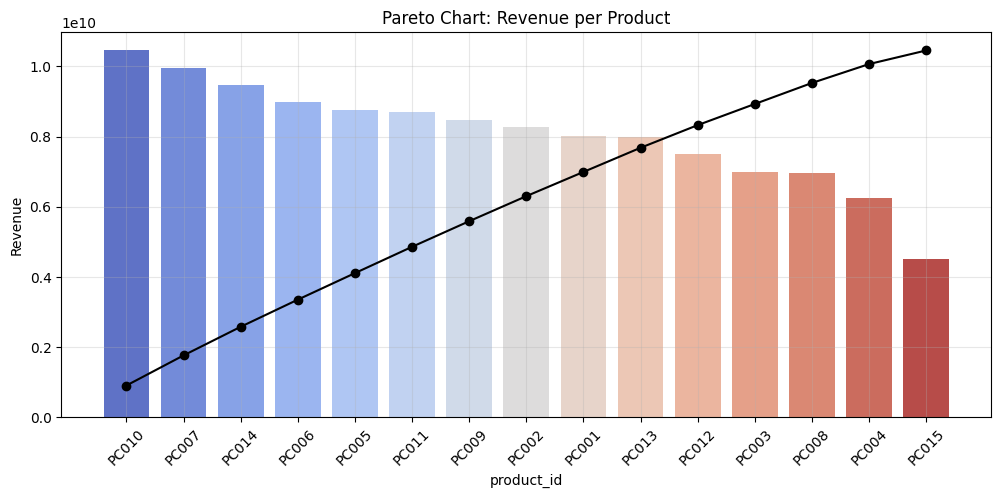

In [22]:
rev = sales.groupby("product_id")["revenue"].sum().sort_values(ascending=False)
cum_share = rev.cumsum() / rev.sum()

plt.figure(figsize=(12,5))
ax = sns.barplot(x=rev.index, y=rev.values, palette="coolwarm")

plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.title("Pareto Chart: Revenue per Product")

# Tambah garis kumulatif
plt.plot(cum_share.index, cum_share.values * rev.max(), color="black", marker="o")
plt.grid(alpha=0.3)
plt.show()


INTERPRETASI:

Secara keseluruhan, data ini menceritakan kisah portofolio yang seimbang. Di satu sisi, ada produk "pekerja keras" bervolume tinggi (seperti PC002, PC005) yang mungkin penting untuk pangsa pasar dan penetrasi. Di sisi lain, ada produk "bintang" berpendapatan tinggi (seperti PC010, PC007) yang kemungkinan merupakan produk premium dan menjadi pendorong utama profitabilitas. Keberhasilan finansial perusahaan ini sangat bergantung pada beberapa produk dan merek utama, terutama Dove.

---



## 3.6. Analisis Region & Channel

Karena data sales mencakup beberapa region dan channel, dilakukan:
- persebaran penjualan per daerah,
- channel dengan kontribusi revenue terbesar,
- perbedaan pola penjualan antar platform e-commerce dan offline.

Insight ini membantu memahami bagaimana strategi distribusi memengaruhi kinerja penjualan.


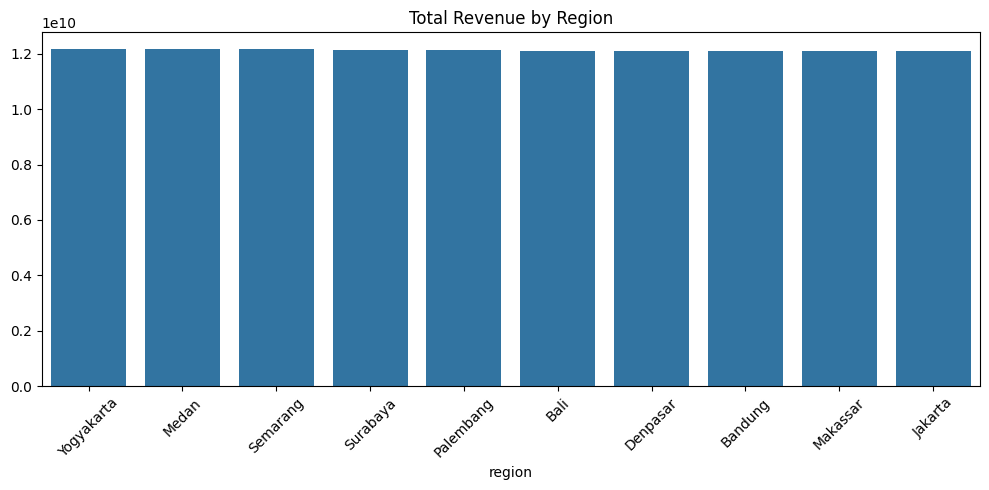

In [23]:
# Revenue by region
plt.figure(figsize=(10, 5))
region_rev = sales.groupby("region")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=region_rev.index, y=region_rev.values)
plt.title("Total Revenue by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

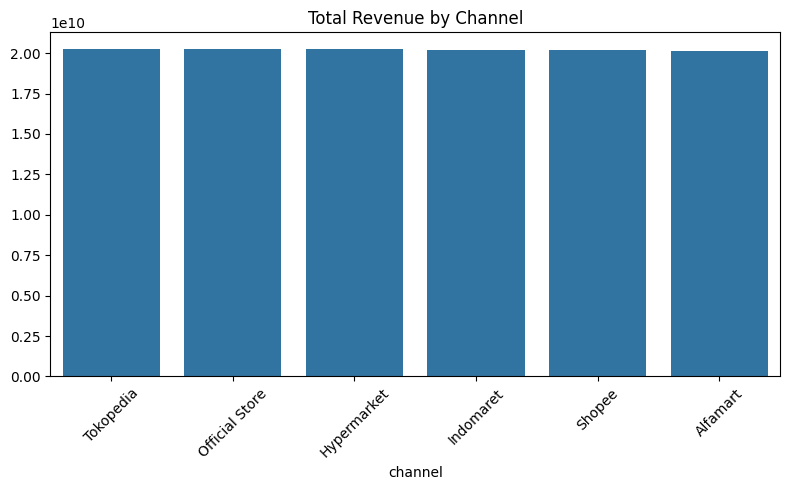

In [24]:
# Revenue by & channel
plt.figure(figsize=(8, 5))
channel_rev = sales.groupby("channel")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=channel_rev.index, y=channel_rev.values)
plt.title("Total Revenue by Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


INTERPRETASI:

Tidak ada perbedaan signifikan terkait total pendapatan di setiap daerah serta setiap channel

---



## 3.7. Analisis Discount, Price, dan Promo Effect

Melihat hubungan:
- harga dasar vs revenue,
- besaran diskon vs tingkat pembelian,
- dampak promo terhadap spike penjualan.

Analisis ini menjadi dasar bagi *price sensitivity* dan strategi promosi.


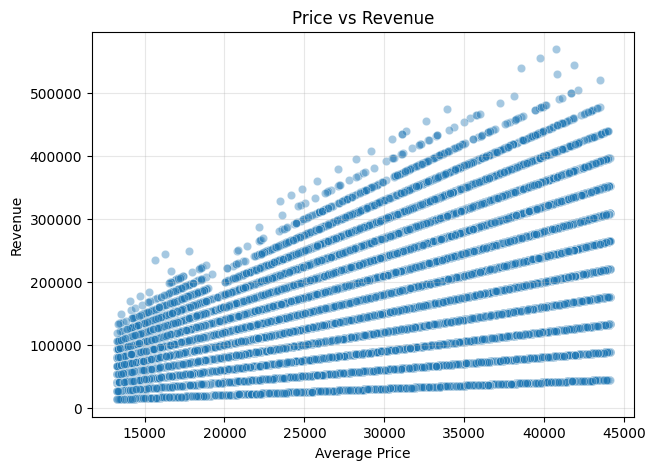

In [25]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=sales, x="avg_price", y="revenue", alpha=0.4)
plt.title("Price vs Revenue")
plt.xlabel("Average Price")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()


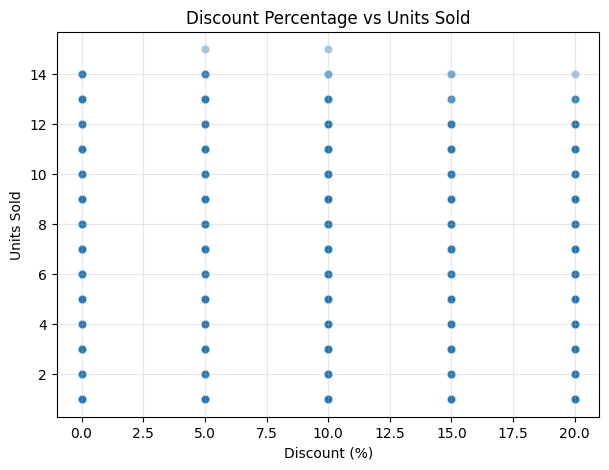

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=sales, x="discount_pct", y="units_sold", alpha=0.4)
plt.title("Discount Percentage vs Units Sold")
plt.xlabel("Discount (%)")
plt.ylabel("Units Sold")
plt.grid(alpha=0.3)
plt.show()


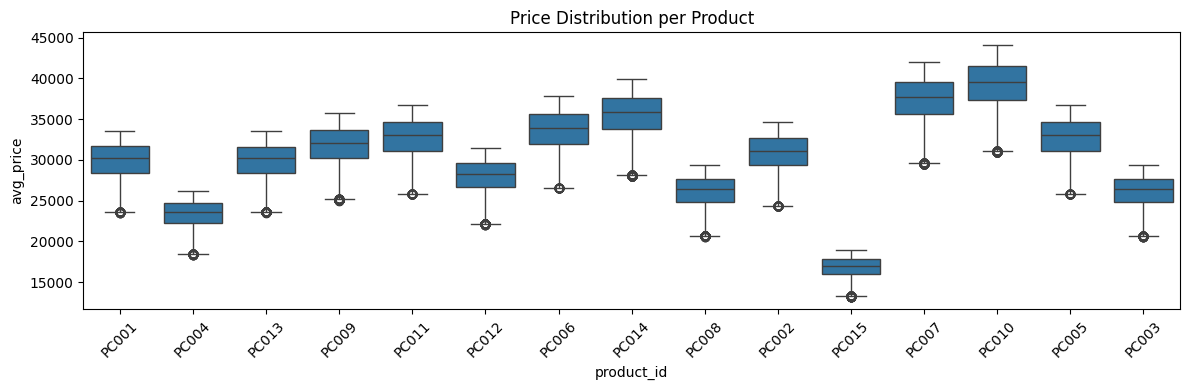

In [27]:
plt.figure(figsize=(12,4))
sns.boxplot(data=sales, x="product_id", y="avg_price")
plt.title("Price Distribution per Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


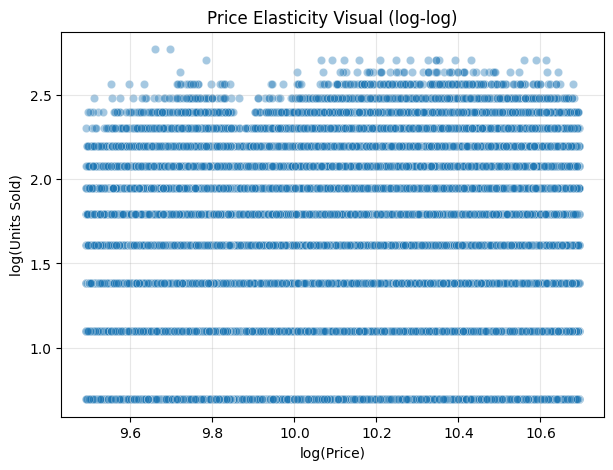

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=np.log(sales["avg_price"] + 1),
    y=np.log(sales["units_sold"] + 1),
    alpha=0.4
)
plt.title("Price Elasticity Visual (log-log)")
plt.xlabel("log(Price)")
plt.ylabel("log(Units Sold)")
plt.grid(alpha=0.3)
plt.show()


INTERPRETASI:

Analisis ini menunjukkan bahwa perusahaan memiliki portofolio yang matang dengan dua strategi jelas: produk premium (seperti PC010, PC007) yang mendorong profitabilitas, dan produk volume (seperti PC002, PC005) yang mengamankan pangsa pasar.

Perusahaan beroperasi di pasar yang sangat stabil dan inelastis, di mana pelanggan tidak sensitif terhadap perubahan harga.

Wawasan paling kritis adalah bahwa strategi diskon saat ini (5-20%) sama sekali tidak efektif. Diskon tersebut gagal mendorong pelanggan untuk membeli lebih banyak unit dan pada dasarnya hanya mengikis margin keuntungan secara sia-sia.

---



## 3.8. Rating Pelanggan & Sentiment Distribution

Data review dianalisis untuk melihat:
- distribusi rating (1–5),
- proporsi sentiment (positive, neutral, negative),
- korelasi awal antara sentiment dengan penjualan.

Insight awal ini akan digunakan untuk NLP dan feature engineering.

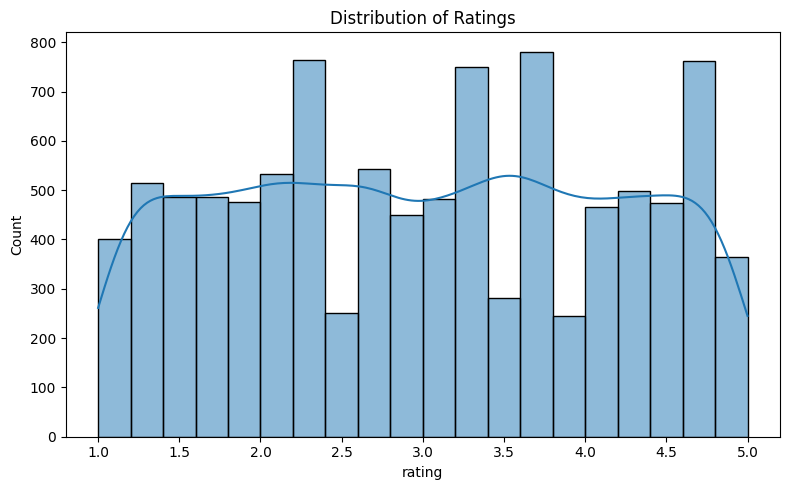

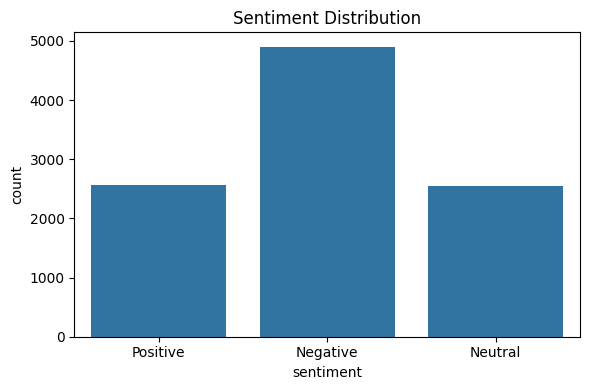

In [29]:
# Distribusi rating & sentiment di reviews
plt.figure(figsize=(8, 5))
sns.histplot(reviews["rating"], kde=True, bins=20)
plt.title("Distribution of Ratings")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=reviews, x="sentiment")
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

INTERPRETASI:

Ada masalah kepuasan pelanggan yang signifikan. Sentimen pelanggan secara keseluruhan didominasi oleh ulasan negatif, yang jumlahnya hampir dua kali lipat ulasan positif atau netral.

Hal ini sejalan dengan distribusi peringkat (rating), yang menunjukkan pengalaman pelanggan sangat tidak konsisten dan terpolarisasi. Alih-alih mendapatkan ulasan bagus secara konsisten, peringkat tersebar di semua tingkatan (dari rendah ke tinggi), menunjukkan bahwa banyak pelanggan memiliki pengalaman yang sangat berbeda—dan sebagian besar cenderung negatif.

---



## 3.9. Korelasi Antar Variabel Numerik

Analisis korelasi dilakukan untuk memahami hubungan antar variabel numerik yang dapat memengaruhi performa penjualan. Heatmap korelasi pada tabel sales menunjukkan bahwa *units_sold* memiliki korelasi positif yang kuat terhadap *revenue*, sehingga jumlah unit terjual merupakan variabel yang paling dominan dalam menentukan pendapatan harian.

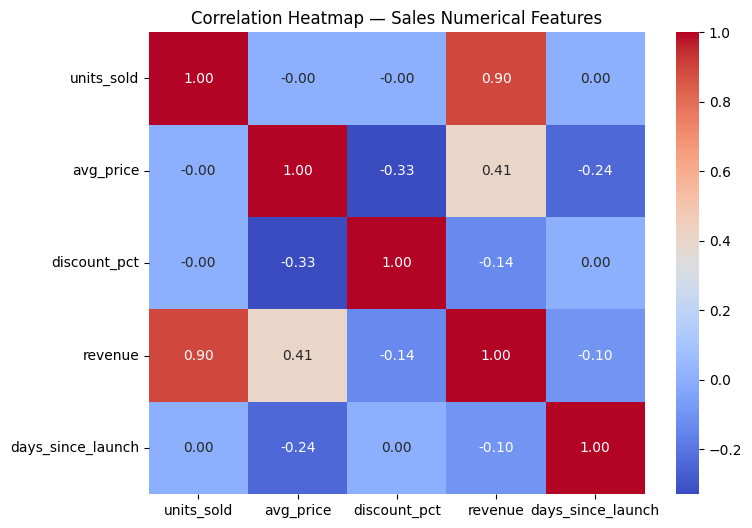

In [30]:
numeric_cols = ["units_sold", "avg_price", "discount_pct", "revenue", "days_since_launch"]

plt.figure(figsize=(8,6))
sns.heatmap(
    sales[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap — Sales Numerical Features")
plt.show()

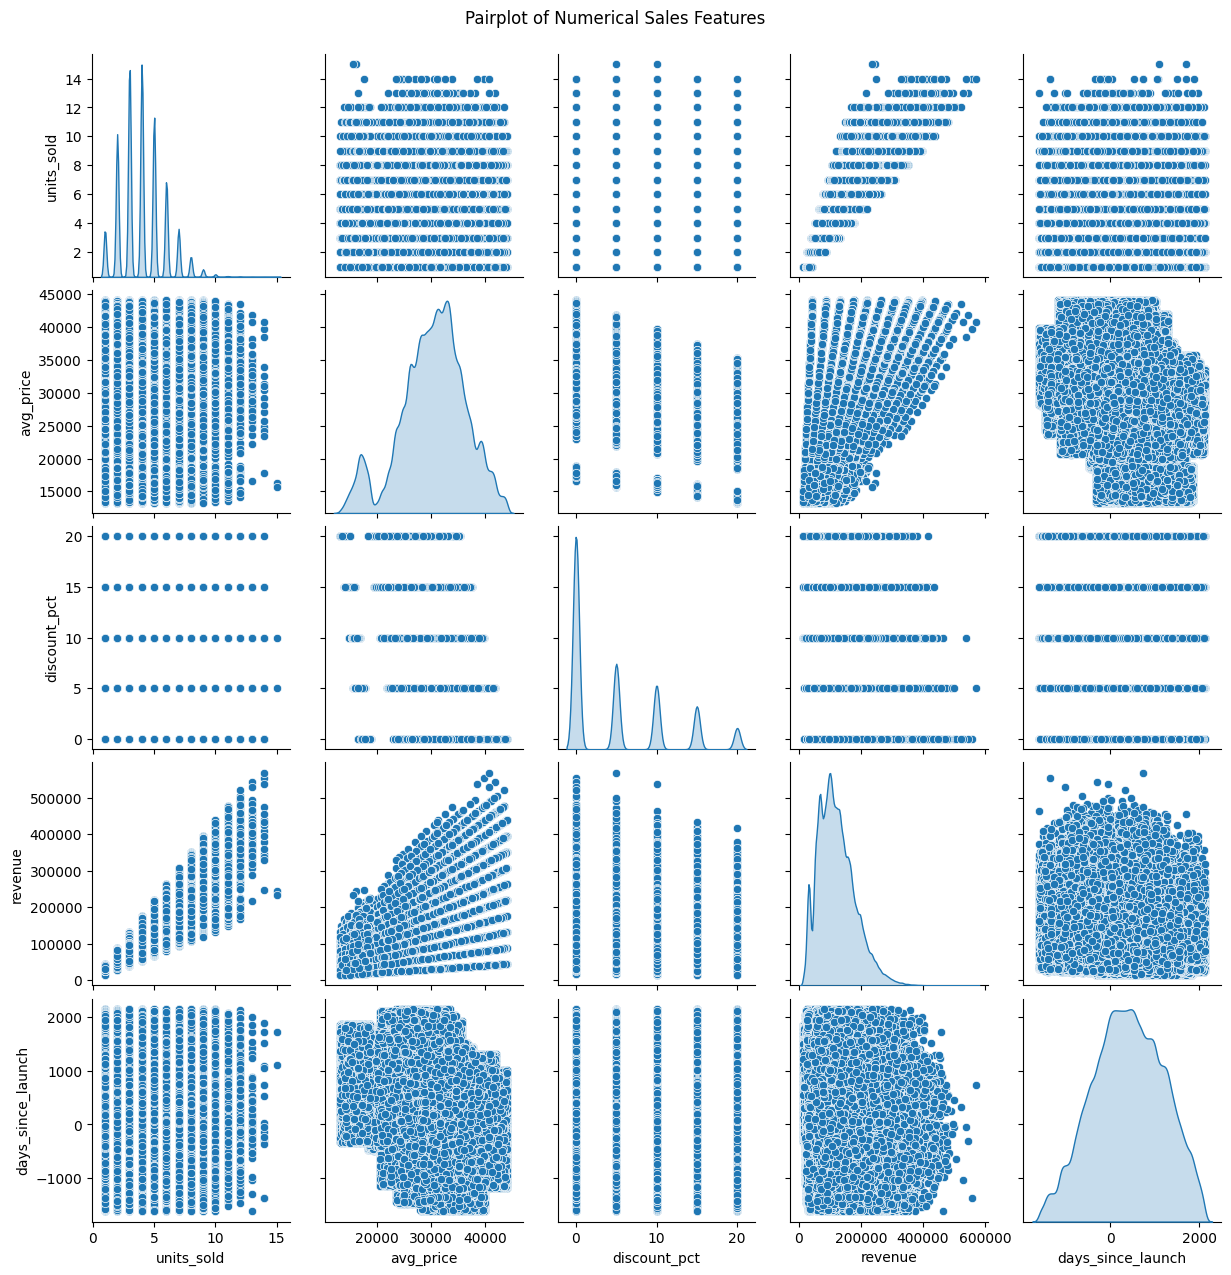

In [31]:
sns.pairplot(sales[numeric_cols], diag_kind="kde")
plt.suptitle("Pairplot of Numerical Sales Features", y=1.02)
plt.show()

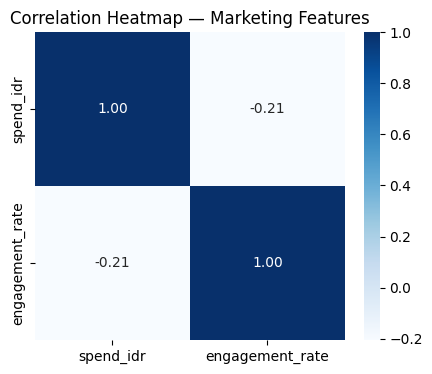

In [32]:
marketing_numeric = ["spend_idr", "engagement_rate"]

plt.figure(figsize=(5,4))
sns.heatmap(
    marketing[marketing_numeric].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Correlation Heatmap — Marketing Features")
plt.show()


INTERPRETASI

Correlation Heatmap, secara statistik menguatkan semua kesimpulan sebelumnya. Analisis seluruh data kini menunjukkan bahwa bisnis ini beroperasi di pasar yang matang, cerdas dalam segmentasi produk, tetapi sangat tidak efisien dan rentan terhadap krisis kepuasan pelanggan.

* Strategi Inti Terbukti: Pendapatan didorong oleh kombinasi kuat dari Volume Penjualan (0.90) dan Harga Rata-Rata (0.41). Ini memvalidasi model di mana produk premium (PC010, PC007) mendorong profitabilitas, sementara produk volume (PC002, PC005) mendorong pangsa pasar (Prinsip Pareto).

* Elastisitas Harga Nirkorelasi: Bukti statistik terkuat adalah: korelasi antara diskon dan unit terjual adalah -0.00 (nol). Secara statistik, diskon sama sekali tidak efektif dalam meningkatkan volume penjualan, yang berarti perusahaan hanya membuang-buang margin keuntungan.

* Ancaman Kualitas: Ancaman ini diperburuk oleh fakta bahwa sentimen pelanggan didominasi oleh ulasan negatif dan peringkat yang terpolarisasi.

KESIMPULAN:

Perusahaan harus segera menghentikan diskon yang sia-sia dan mengalihkan fokus untuk menyelesaikan krisis kualitas yang mendasari ulasan negatif, sebelum produk premium yang sangat menguntungkan kehilangan kredibilitas dan pangsa pasar mereka.

---



## 3.10. Ringkasan Akhir Analisis Data Eksplorasi (EDA)

Analisis ini menyimpulkan bahwa bisnis ini memiliki struktur finansial yang matang dan stabil namun menghadapi inefisiensi strategis dan **risiko kualitas pelanggan yang signifikan.

### I. Struktur Portofolio & Keuangan (Kekuatan)

| Area | Temuan Utama | Implikasi |
| :--- | :--- | :--- |
| **Segmentasi Produk** | Terdapat pembagian jelas antara produk **Premium** (pendapatan tinggi, harga tinggi: **PC010, PC007**) dan produk **Volume** (unit tinggi, harga menengah: **PC002, PC005**). | Strategi *mixed* portofolio berhasil mempertahankan margin dan pangsa pasar. |
| **Kontribusi Merek** | Merek **Dove** adalah kontributor pendapatan terbesar. Pendapatan secara umum sangat terkonsentrasi (**Prinsip Pareto**). | Kesehatan finansial sangat bergantung pada kinerja segelintir produk dan merek premium. |
| **Stabilitas Pasar** | Tren pendapatan jangka panjang (2020-2026) **datar dan stabil**, namun terdapat **volatilitas bulanan yang kuat dan berulang**. | Bisnis adalah *cash cow* yang membutuhkan perencanaan operasional musiman yang cermat. |
| **Distribusi** | Kontribusi pendapatan **seimbang** di seluruh saluran penjualan (E-commerce, Toko Ritel, Hipermarket). | Tidak ada ketergantungan berlebihan pada satu *channel* tertentu. |



### II. Dinamika Harga & Pemasaran (Anomali Kritis)

#### Inefisiensi Promosi & Inelastisitas

* **Pasar Inelastis:** Analisis menunjukkan bahwa pelanggan **tidak sensitif terhadap harga**; perubahan harga tidak berkorelasi dengan peningkatan unit penjualan.
* **Diskon Tidak Efektif:** Secara statistik, korelasi antara **persentase diskon** dan **unit terjual** adalah **nol (0.00)**.
    > **Kesimpulan:** Diskon (5% hingga 20%) gagal mendorong pelanggan untuk membeli unit lebih banyak dan hanya berfungsi sebagai **pemborosan margin** yang dapat dihindari.

#### Penggerak Pendapatan

* Pendapatan memiliki korelasi **sangat kuat (0.90)** dengan **Units Sold**, dan korelasi **kuat (0.41)** dengan **Average Price**.


### III. Kualitas & Sentimen Pelanggan (Risiko Terbesar)

#### Krisis Kualitas

* **Sentimen Negatif Dominan:** Jumlah ulasan dengan sentimen **Negatif** hampir dua kali lipat dari ulasan Positif.
* **Polarisasi Peringkat:** Distribusi peringkat pelanggan tersebar luas dengan banyak puncak.
    > **Kesimpulan:** Hal ini mengindikasikan **inkonsistensi parah** dalam kualitas produk atau pengalaman layanan.



### Rekomendasi Tindak Lanjut

* **Fokus:** Hentikan segera strategi diskon berbasis persentase.
* **Aksi:** Alihkan sumber daya yang dihemat dari diskon untuk menyelesaikan **masalah kualitas mendasar** yang menyebabkan gelombang sentimen negatif dan peringkat buruk.

---



# 4. Feature Engineering (Innovation Radar)

Pada tahap ini, seluruh data mentah dari sales, products, dan marketing diolah menjadi dataset harian yang lengkap dan siap digunakan untuk proses pemodelan. Feature engineering dilakukan dalam dua langkah besar: pembuatan fitur penjualan harian dan pembuatan fitur marketing harian. Hasil akhirnya berupa satu tabel daily_prod yang menggabungkan performa penjualan, karakteristik produk, aktivitas pemasaran, dan fitur waktu.

## 4.1. Membentuk Fitur Penjualan Harian per Produk

Pada bagian pertama, data transaksi yang awalnya bersifat granular (per transaksi) diringkas menjadi data harian untuk setiap produk.

In [33]:
daily_prod = (
    sales.groupby(["date","product_id"], as_index=False)
    .agg(
        total_units_sold=("units_sold","sum"),
        total_revenue=("revenue","sum"),
        avg_price=("avg_price","mean"),
        avg_discount=("discount_pct","mean"),
        avg_days_since_launch=("days_since_launch","mean"),
        n_regions=("region","nunique"),
        n_channels=("channel","nunique"),
    )
)

daily_prod = daily_prod.merge(products, on="product_id", how="left")

daily_prod["year"] = daily_prod["date"].dt.year
daily_prod["month"] = daily_prod["date"].dt.month
daily_prod["dow"] = daily_prod["date"].dt.dayofweek
daily_prod["is_weekend"] = daily_prod["dow"].isin([5,6]).astype(int)

## 4.2 Membentuk Fitur Marketing Harian

Data marketing awalnya berupa kampanye dengan rentang tanggal. Agar dapat digabungkan ke tingkat harian, setiap kampanye “diexpand” menjadi data per hari selama masa aktif kampanye.

In [34]:

rows = []
for _, r in marketing.iterrows():
    for d in pd.date_range(r.start_date, r.end_date):
        rows.append({
            "product_id": r.product_id,
            "date": d,
            "spend": r.spend_idr,
            "engagement": r.engagement_rate,
            "channel": r.channel
        })

marketing_daily = pd.DataFrame(rows)

mkt_agg = (
    marketing_daily.groupby(["date","product_id"], as_index=False)
    .agg(
        total_spend=("spend","sum"),
        mean_engagement=("engagement","mean"),
        n_channels_mkt=("channel","nunique")
    )
)

daily_prod = daily_prod.merge(mkt_agg, on=["date","product_id"], how="left")
daily_prod.fillna(0, inplace=True)


## 4.3 Visualisasi Hasil Feature Engineering

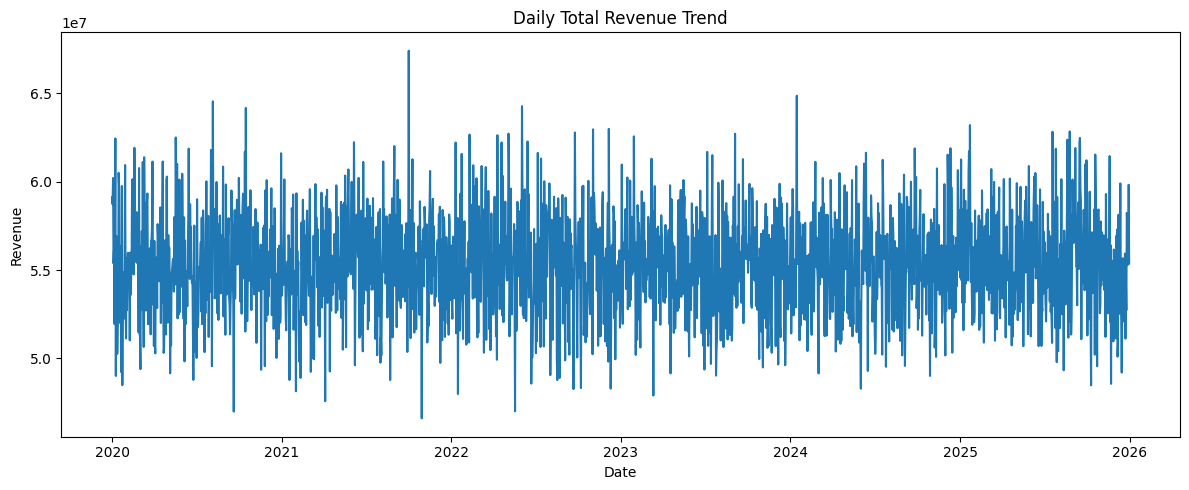

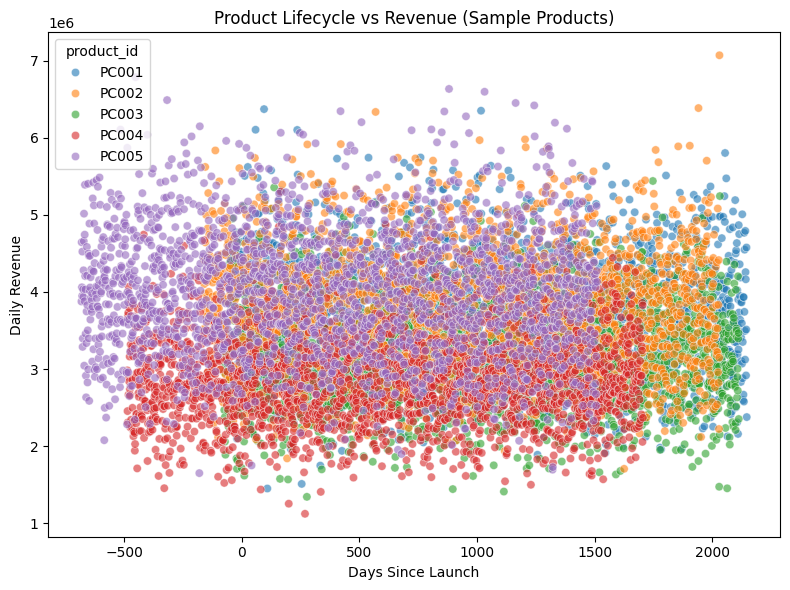

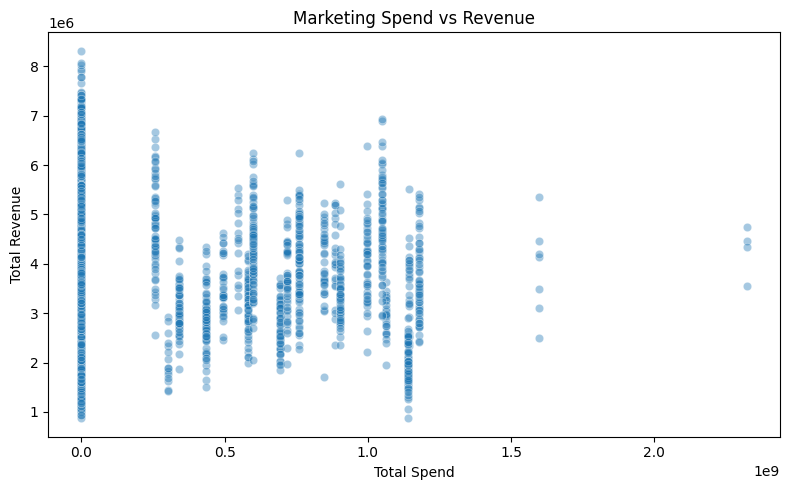

In [35]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=daily_prod.groupby("date")["total_revenue"].sum().reset_index(),
    x="date", y="total_revenue"
)
plt.title("Daily Total Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

sample_products = daily_prod["product_id"].unique()[:5]  # ambil 5 produk saja biar bersih
subset = daily_prod[daily_prod["product_id"].isin(sample_products)]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=subset,
    x="avg_days_since_launch",
    y="total_revenue",
    hue="product_id",
    palette="tab10",
    alpha=0.6
)
plt.title("Product Lifecycle vs Revenue (Sample Products)")
plt.xlabel("Days Since Launch")
plt.ylabel("Daily Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=daily_prod,
    x="total_spend",
    y="total_revenue",
    alpha=0.4
)
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Total Spend")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


INTERPRETASI:

* Revenue harian stabil tetapi penuh noise, sesuai karakteristik FMCG.

* Lifecycle produk tidak menjadi penentu utama revenue.

* Marketing spend sendirian tidak cukup menjelaskan variasi revenue.

* Insight ini mendukung penggunaan model machine learning yang mampu menangani interaksi kompleks antar fitur.

# 5. NLP Feature Engineering (Innovation Radar)

In [36]:
reviews.head()

,review_id,product_id,date,rating,sentiment,platform,comment
0,R100000,PC014,2024-10-16,4.6,Positive,Instagram,"Packaging bocor saat diterima, kurang aman."
1,R100001,PC012,2023-06-27,2.8,Negative,Instagram,"Mudah dibeli saat promo, value for money."
2,R100002,PC003,2022-10-21,3.2,Neutral,Shopee,"Mudah dibeli saat promo, value for money."
3,R100003,PC010,2025-03-07,2.0,Negative,Tokopedia,"Mudah dibeli saat promo, value for money."
4,R100004,PC015,2022-03-03,1.5,Negative,Shopee,Memberikan hasil sesuai klaim after 2 weeks.


Mengapa perlu NLP?

Dalam data ulasan ditemukan banyak kasus rating tidak sesuai dengan isi komentar, seperti:

* rating tinggi tapi ulasan bernada negatif,

* rating rendah tapi komentar justru positif.

Rating sering tidak akurat karena dipengaruhi faktor di luar kualitas produk (pengiriman, promo, kebiasaan pengguna, atau ulasan otomatis). Akibatnya, rating saja tidak cukup untuk menangkap sentimen sebenarnya.

Dengan NLP, teks ulasan bisa dibaca dan dipahami secara langsung sehingga model dapat:

* mendeteksi sentimen yang lebih akurat,

* mengenali keluhan atau pujian yang tidak tercermin pada rating,

* menambah sinyal penting yang tidak tersedia di angka rating.

Karena mismatch ini, NLP menjadi fitur penting untuk memahami persepsi pelanggan secara lebih realistis.

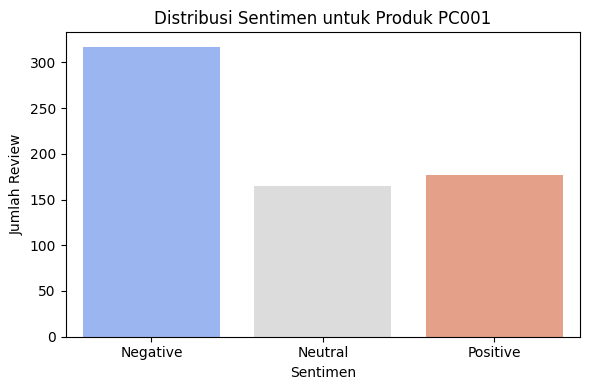

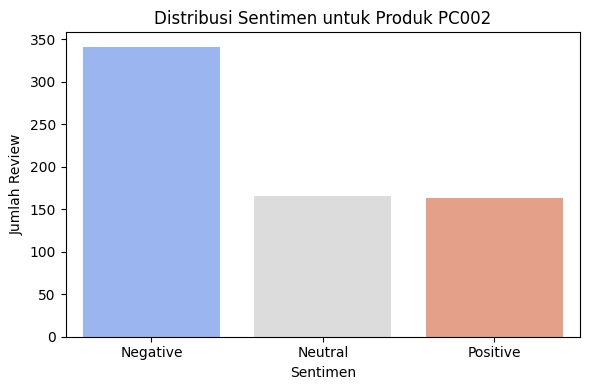

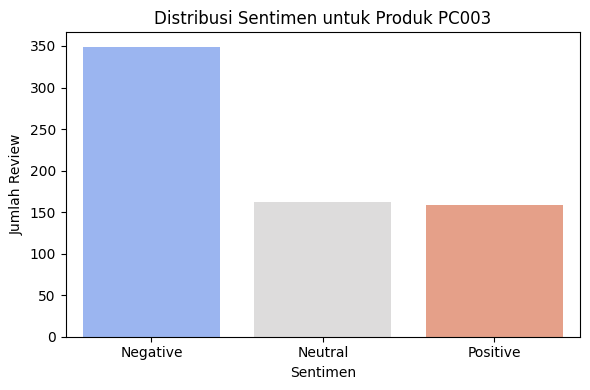

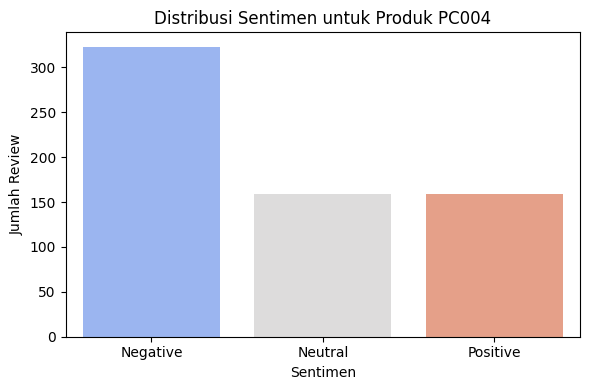

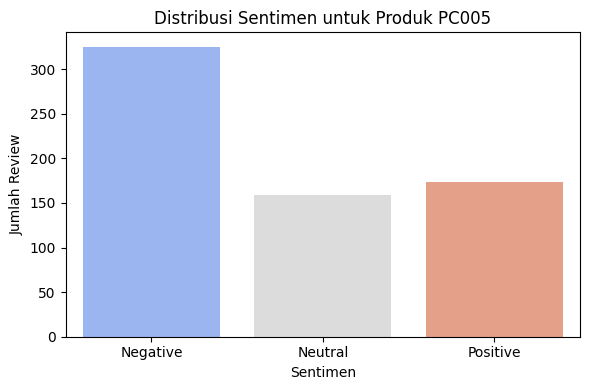

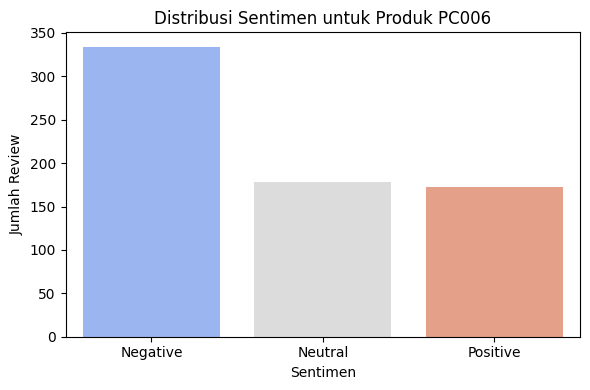

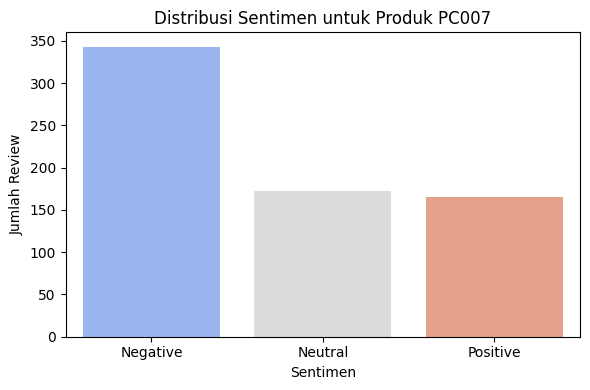

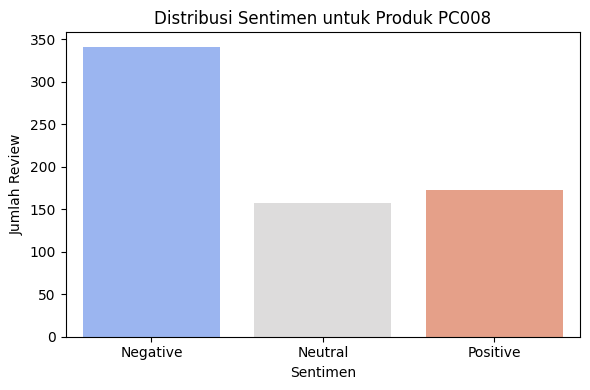

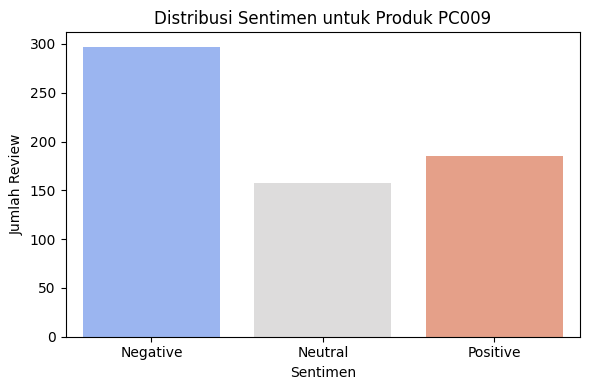

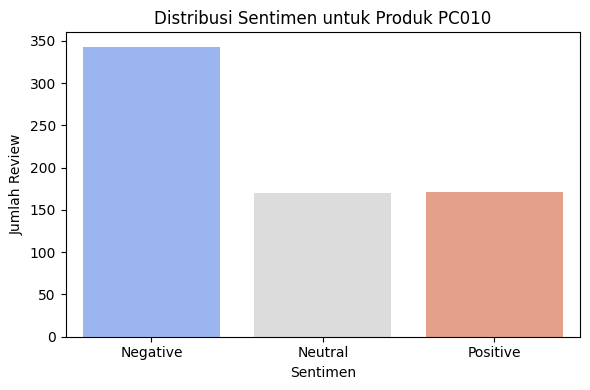

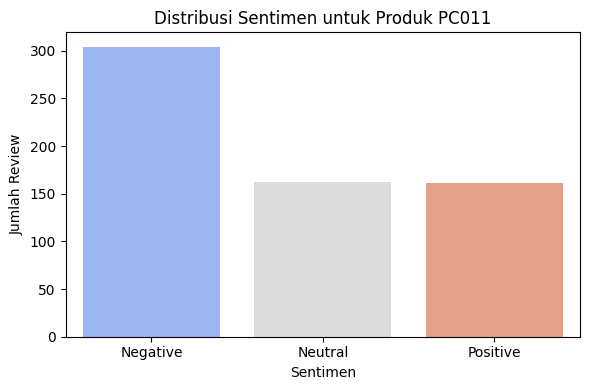

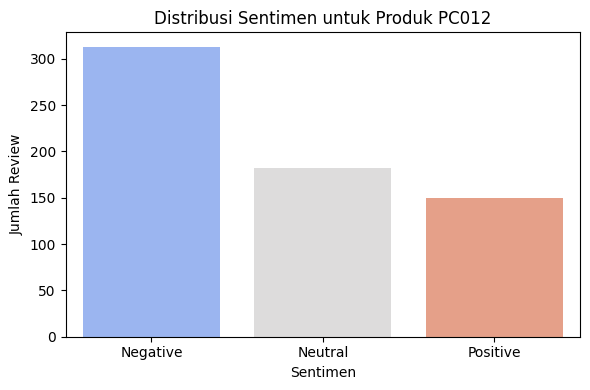

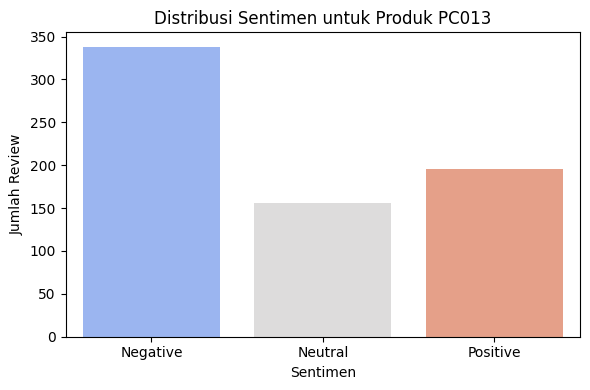

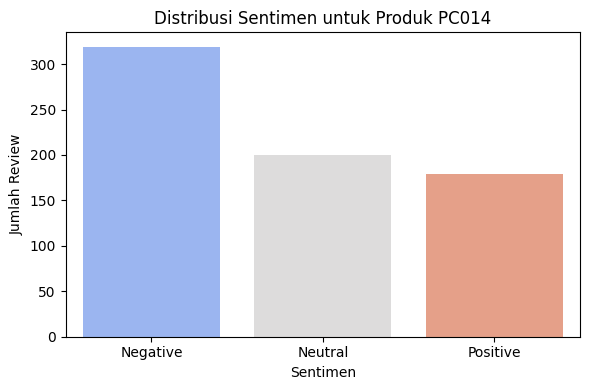

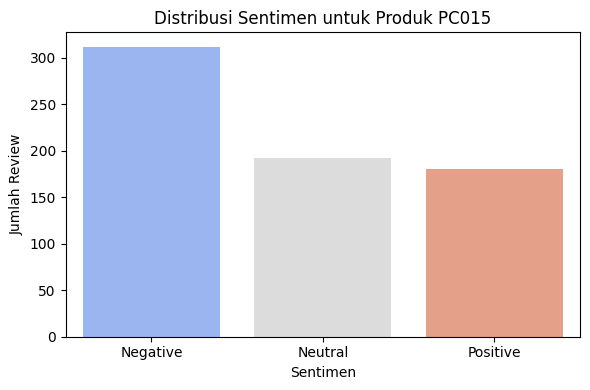

In [97]:
sentiment_counts = (
    reviews.groupby(['product_id', 'sentiment'])
    .agg(jumlah=('review_id', 'count'))
    .reset_index()
)

# List unik product_id
products = sentiment_counts['product_id'].unique()

# Loop untuk bikin visualisasi tiap produk
for p in products:
    df_p = sentiment_counts[sentiment_counts['product_id'] == p]

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df_p,
        x="sentiment",
        y="jumlah",
        palette="coolwarm"
    )

    plt.title(f"Distribusi Sentimen untuk Produk {p}")
    plt.xlabel("Sentimen")
    plt.ylabel("Jumlah Review")

    plt.tight_layout()
    plt.show()

In [40]:
stop_words = set(stopwords.words("indonesian"))

# 1. CLEANING FUNCTION
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"\d+", "", t)
    t = t.translate(str.maketrans("", "", string.punctuation))
    t = " ".join([w for w in t.split() if w not in stop_words])
    return t

reviews["clean"] = reviews["comment"].apply(clean_text)

# 2. TF-IDF REPRESENTATION
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(reviews["clean"])

tfidf_dense = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)
tfidf_dense["review_id"] = reviews["review_id"]


# 3. SENTIMENT ENCODING (label bawaan dataset)
sentiment_map = {"Negative": -1, "Neutral": 0, "Positive": 1}
reviews["sentiment_encoded"] = reviews["sentiment"].map(sentiment_map)

# 4. TRAIN CUSTOM SENTIMENT CLASSIFIER
X_sent = tfidf_matrix
y_sent = reviews["sentiment_encoded"]

# bisa pakai LogisticRegression
sent_clf = LogisticRegression(max_iter=2000)
sent_clf.fit(X_sent, y_sent)

reviews["sentiment_pred"] = sent_clf.predict(X_sent)
reviews["sentiment_pred_score"] = sent_clf.predict_proba(X_sent).max(axis=1)

# 5. TOPIC MODELING — LSA
lsa = TruncatedSVD(n_components=20)
lsa_features = lsa.fit_transform(tfidf_matrix)

lsa_df = pd.DataFrame(
    lsa_features,
    columns=[f"lsa_{i}" for i in range(20)]
)
lsa_df["review_id"] = reviews["review_id"]

# 6. TOPIC MODELING — LDA
lda = LatentDirichletAllocation(n_components=8)
lda_features = lda.fit_transform(tfidf_matrix)

lda_df = pd.DataFrame(
    lda_features,
    columns=[f"topic_{i}" for i in range(8)]
)
lda_df["review_id"] = reviews["review_id"]


# 7. BERT EMBEDDINGS
bert = SentenceTransformer("all-MiniLM-L6-v2")
bert_embeddings = bert.encode(reviews["clean"], show_progress_bar=True)

bert_df = pd.DataFrame(
    bert_embeddings,
    columns=[f"bert_{i}" for i in range(384)]
)
bert_df["review_id"] = reviews["review_id"]

# 8. MERGE SEMUA NLP FEATURE LEVEL REVIEW
nlp_full = (
    reviews[[
        "review_id",
        "product_id",
        "date",
        "rating",
        "sentiment_encoded",
        "sentiment_pred",
        "sentiment_pred_score"
    ]]
    .merge(lsa_df, on="review_id")
    .merge(lda_df, on="review_id")
    .merge(bert_df, on="review_id")
)

# 9. AGGREGATE NLP FEATURES PER PRODUCT PER DAY
nlp_daily = (
    nlp_full.groupby(["product_id","date"])
    .agg({
        "rating": "mean",
        "sentiment_encoded": "mean",      # sentiment asli
        "sentiment_pred": "mean",         # sentiment model
        "sentiment_pred_score": "mean",   # confidence model
        **{col: "mean" for col in lsa_df.columns if col != "review_id"},
        **{col: "mean" for col in lda_df.columns if col != "review_id"},
        **{col: "mean" for col in bert_df.columns if col != "review_id"},
    })
    .reset_index()
)

# 10. MERGE NLP → daily_prod
daily_merged = daily_prod.merge(nlp_daily, on=["product_id","date"], how="left")
daily_merged.fillna(0, inplace=True)

print("NLP block completed. daily_merged shape:", daily_merged.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

NLP block completed. daily_merged shape: (32880, 438)


# 6. Modeling
Pada tahap ini, tujuan utama adalah membangun model regresi yang mampu memprediksi total_revenue harian setiap produk berdasarkan berbagai fitur hasil Feature Engineering. Model regresi dipilih karena target yang diprediksi merupakan nilai kontinu, sehingga metrik evaluasi seperti RMSE, MAE, dan R² dapat digunakan secara tepat dan terukur.

## 6.1 Train-test Split & Preprocessing

Dataset dipisahkan menggunakan batas waktu (cutoff).
Semua data sebelum 1 Januari 2024 digunakan sebagai training, sedangkan data mulai 2024 menjadi testing.
Metode ini sesuai untuk data berbasis waktu agar model tidak melihat data masa depan saat dilatih.

In [41]:
train = daily_merged[daily_merged.date < "2024-01-01"]
test  = daily_merged[daily_merged.date >= "2024-01-01"]

y_train = train["total_revenue"]
y_test = test["total_revenue"]

num_cols = ["total_units_sold","avg_price","avg_discount","avg_days_since_launch","total_spend"]
cat_cols = ["product_id","brand","type"]
nlp_cols = [c for c in daily_merged.columns if c.startswith(("lsa","topic","bert"))]

X_train = train[num_cols + cat_cols + nlp_cols]
X_test  = test[num_cols + cat_cols + nlp_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("nlp", "passthrough", nlp_cols),
    ]
)

## 6.2 Baseline Model Menggunakan Random Forest

Random Forest digunakan sebagai baseline karena:

* stabil tanpa tuning,

* tahan outlier,

* menangani non-linear dengan baik,

* fleksibel dengan banyak tipe fitur,

* dan memberi titik referensi untuk mengevaluasi apakah model lain benar-benar lebih baik.

In [42]:
# Baseline : Random Forest
rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))

KeyboardInterrupt: 

## 6.3 Hyperparameter Tuning

Kode untuk tuning kita buat sebagai comment karena memakan waktu sangat lama ketika dijalankan sehingga kami menggantinya dengan best param yang kami dapatkan dan kami simpan di tuning sebelumnya.

In [ ]:
# RANDOM FOREST
"""
Kode ini tidak dijalankan karena memakan waktu sangat lama sehingga kami menggantinya
dengan best param yang kami dapatkan di tuning sebelumnya.
"""
"""
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 200, 800)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 15)

    model = Pipeline([
        ("prep", preprocess),
        ("rf", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("BEST PARAMS:", study.best_params)
"""


In [43]:
# Best param yang didapat dari hyperparameter tuning sebelumnya untuk Random Forest
best_params_saved = {
    'n_estimators': 322,
    'max_depth': 12,
    'min_samples_split': 6
}

best_params = best_params_saved

In [44]:
# Retrain best model

best_rf = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    random_state=42,
    n_jobs=-1
)

rf_model = Pipeline([
    ("prep", preprocess),
    ("model", best_rf)
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['total_units_sold',
                                                   'avg_price', 'avg_discount',
                                                   'avg_days_since_launch',
                                                   'total_spend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['product_id', 'brand',
                                                   'type']),
                                                 ('nlp', 'passthrough',
                                                  ['lsa_0', 'lsa_1', 'lsa_2',
                                                   'lsa_3', 'lsa_4', 'lsa_5',
                                                   'lsa_6', 'lsa_7', 'lsa_8',
                                                   'lsa_9', 'lsa_10', 'lsa_11',
                                                   'lsa_12', 'lsa_13', 'lsa_14',
                                                   'lsa_15', 'lsa_16', 'lsa_17',
                                                   'lsa_18', 'lsa_19',
                                                   'topic_0', 'topic_1',
                                                   'topic_2', 'topic_3',
                                                   'topic_4', 'topic_5',
                                                   'topic_6', 'topic_7',
                                                   'bert_0', 'bert_1', ...])])),
                ('model',
                 RandomForestRegressor(max_depth=12, min_samples_split=6,
                                       n_estimators=322, n_jobs=-1,
                                       random_state=42))])

In [ ]:
# XGBBOOST
"""
Kode ini tidak dijalankan karena memakan waktu sangat lama sehingga kami menggantinya
dengan best param yang kami dapatkan di tuning sebelumnya.
"""
"""
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 4, 14),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
    }

    model = Pipeline([
        ("prep", preprocess),
        ("model", XGBRegressor(
            tree_method="hist",
            random_state=42,
            **params
        ))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return rmse

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)

best_params_xgb = study_xgb.best_params
best_params_xgb
"""


In [45]:
# Best param yang didapat dari hyperparameter tuning sebelumnya untuk XGBOOST
best_params_xgb_saved = {
    "n_estimators": 906,
    "max_depth": 4,
    "learning_rate": 0.06922576564163467,
    "subsample": 0.9768279506103699,
    "colsample_bytree": 0.7280962009495473
}

best_params_xgb = best_params_xgb_saved

In [46]:
# Retrain best model
xgb_model = Pipeline([
    ("prep", preprocess),
    ("model", XGBRegressor(
        tree_method="hist",
        random_state=42,
        **best_params_xgb
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['total_units_sold',
                                                   'avg_price', 'avg_discount',
                                                   'avg_days_since_launch',
                                                   'total_spend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['product_id', 'brand',
                                                   'type']),
                                                 ('nlp', 'passthrough',
                                                  ['lsa_0', 'lsa_1', 'lsa_2',
                                                   'lsa_3', 'lsa_4', 'lsa_5',
                                                   'lsa_6', 'lsa_7', 'lsa_8',
                                                   'lsa_9', 'lsa...
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.06922576564163467, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=906, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
# LIGHTGBM
"""
Kode ini tidak dijalankan karena memakan waktu sangat lama sehingga kami menggantinya
dengan best param yang kami dapatkan di tuning sebelumnya.
"""

"""
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", -1, 14),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
    }

    model = Pipeline([
        ("prep", preprocess),
        ("model", LGBMRegressor(
            random_state=42,
            **params
        ))
    ])

    model.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return rmse

study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=25)

best_params_lgb = study_lgb.best_params
best_params_lgb
"""

In [47]:
best_params_lgb_saved = {
    "n_estimators": 1030,
    "learning_rate": 0.1676579546734721,
    "num_leaves": 52,
    "max_depth": 10,
    "subsample": 0.8716939292020666,
    "colsample_bytree": 0.8323857521861227
}

best_params_lgb = best_params_lgb_saved

In [48]:
# Retrain best model
lgbm_model = Pipeline([
    ("prep", preprocess),
    ("model", LGBMRegressor(random_state=42, **best_params_lgb))
])

lgbm_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25793
[LightGBM] [Info] Number of data points in the train set: 21915, number of used features: 448
[LightGBM] [Info] Start training from score 3686667.273021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['total_units_sold',
                                                   'avg_price', 'avg_discount',
                                                   'avg_days_since_launch',
                                                   'total_spend']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['product_id', 'brand',
                                                   'type']),
                                                 ('nlp', 'passthrough',
                                                  ['lsa_0', 'lsa_1', 'lsa_2',
                                                   'lsa_3', 'lsa_4', 'lsa_5',
                                                   'lsa_6', 'lsa_7', 'lsa_8',
                                                   'lsa_9', 'lsa...
                                                   'lsa_12', 'lsa_13', 'lsa_14',
                                                   'lsa_15', 'lsa_16', 'lsa_17',
                                                   'lsa_18', 'lsa_19',
                                                   'topic_0', 'topic_1',
                                                   'topic_2', 'topic_3',
                                                   'topic_4', 'topic_5',
                                                   'topic_6', 'topic_7',
                                                   'bert_0', 'bert_1', ...])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8323857521861227,
                               learning_rate=0.1676579546734721, max_depth=10,
                               n_estimators=1030, num_leaves=52,
                               random_state=42,
                               subsample=0.8716939292020666))])

## 6.4 Evaluasi Model Terbaik

In [49]:
# EVALUATE BEST MODEL

def eval_model(name, model):
    pred = model.predict(X_test)
    return {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    }

results = [
    eval_model("RandomForest (tuned)", rf_model),
    eval_model("XGBoost (tuned)", xgb_model),
    eval_model("LightGBM (tuned)", lgbm_model)
]

pd.DataFrame(results)


,Model,RMSE,MAE,R2
0,RandomForest (tuned),27669.700903,20594.073329,0.999231
1,XGBoost (tuned),26971.381955,20942.235536,0.999269
2,LightGBM (tuned),31884.357874,23971.340466,0.998979


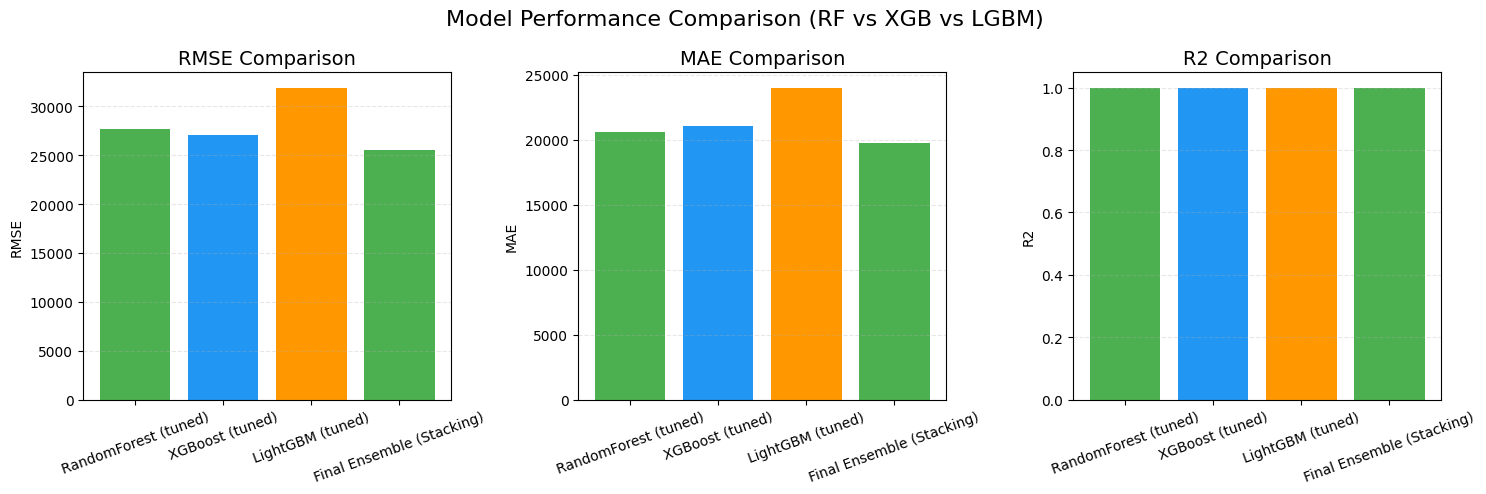

In [94]:
# VISUALIZATION OF BEST MODEL

# Convert result list ke DataFrame
df_results = pd.DataFrame(results)

# Buat subplots 1 row 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ["RMSE", "MAE", "R2"]
colors = ["#4CAF50", "#2196F3", "#FF9800"]

for i, metric in enumerate(metrics):
    axes[i].bar(df_results["Model"], df_results[metric], color=colors)
    axes[i].set_title(f"{metric} Comparison", fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Model Performance Comparison (RF vs XGB vs LGBM)", fontsize=16)
plt.tight_layout()
plt.show()

INTERPRETASI:

* XGBoost adalah model terbaik untuk memprediksi total_revenue dalam dataset ini.

* Random Forest sangat kompetitif dan menunjukkan bahwa struktur fitur yang digunakan sudah tepat.

* LightGBM masih akurat, tetapi tidak menandingi dua model lainnya setelah tuning.

# 7. Statistical Regression (OLS) & Uji Asumsi

Bagian ini menggunakan pendekatan Ordinary Least Squares (OLS) untuk memahami hubungan linear antara fitur-fitur utama dan total_revenue. Berbeda dengan model machine learning yang fokus pada akurasi prediksi, OLS digunakan untuk analisis statistik, yaitu:

* mengidentifikasi fitur mana yang signifikan,

* melihat arah pengaruh (positif/negatif),

* mengevaluasi linearitas hubungan,

* dan memeriksa asumsi-asumsi dasar regresi.

OLS dijalankan menggunakan seluruh dataset (tanpa train-test split) karena tujuannya adalah analisis hubungan, bukan prediksi masa depan.

## 7.1 Ordinary Least Square (OLS)

In [51]:
# 1. Feature Selection (fit OLS with full data, no split)
ols_features = [
    "total_units_sold",
    "avg_price",
    "avg_discount",
    "avg_days_since_launch",
    "total_spend",
    "mean_engagement",
    "n_regions",
    "n_channels",
    "sentiment_encoded",
    "sentiment_pred",
    "sentiment_pred_score",
    "rating",
]

ols_df = daily_merged[ols_features + ["total_revenue"]].copy()

# 2. Cleaning
ols_df = ols_df.replace([np.inf, -np.inf], np.nan).dropna()

# 3. X dan y (full dataset)
X_ols = ols_df[ols_features]
y_ols = ols_df["total_revenue"]

# 4. Add constant (wajib untuk OLS)
import statsmodels.api as sm

X_const = sm.add_constant(X_ols)

# 5. Fit OLS (full dataset, not split!!)
ols_model = sm.OLS(y_ols, X_const).fit()

# 6. Summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_revenue   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 1.480e+05
Date:                Sat, 15 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:34:48   Log-Likelihood:            -4.3485e+05
No. Observations:               32880   AIC:                         8.697e+05
Df Residuals:                   32867   BIC:                         8.698e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -3.672e+

## 7.1 Uji Hipotesis Nol (H0: β = 0)

Cek fitur mana yang signifikan (p-value < 0.05)

In [54]:
uji_hipotesis = (
    pd.DataFrame({
        "coef": ols_model.params,
        "p_value": ols_model.pvalues,
        "significant_05": ols_model.pvalues < 0.05
    })
    .sort_values("p_value")
)

display(uji_hipotesis)

,coef,p_value,significant_05
const,-3.671565e+06,0.000000,True
total_units_sold,3.024177e+04,0.000000,True
avg_price,1.217620e+02,0.000000,True
mean_engagement,3.397010e+04,0.096247,False
avg_discount,9.609554e+02,0.143042,False
sentiment_encoded,-5.481829e+03,0.231960,False
n_channels,-4.335120e+03,0.265015,False
n_regions,1.021940e+03,0.382026,False
rating,2.567676e+03,0.437669,False
sentiment_pred_score,-3.804047e+04,0.578416,False


INTERPRETASI:

Jadi menurut analisis statistik linear,hanya ada 2 fitur yang benar-benar punya pengaruh revenue dalam hubungan LINIER:

* total_units_sold

* avg_price

Fitur lainnya mungkin berpengaruh secara non-linear (kompleks), yang ditangkap oleh ML model seperti XGBoost, tapi tidak oleh OLS.

---



## 7.2 Uji Normalitas Residual

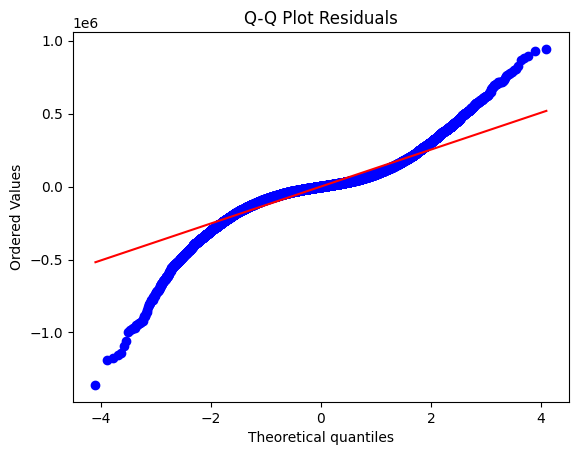

In [52]:
residuals = ols_model.resid

import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot Residuals")
plt.show()

INTERPRETASI:

Residual OLS tidak mengikuti distribusi normal, terlihat dari pola lengkung pada Q–Q plot. Hal ini menunjukkan adanya non-normality dan kemungkinan heteroskedastisitas. Penyebabnya adalah struktur data revenue yang kompleks, non-linear, dan memiliki variasi ekstrem. Meski demikian, OLS tetap digunakan di sini untuk analisis signifikansi fitur, bukan sebagai model prediksi utama.

---



## 7.3 Uji Homoskedastisitas (Breusch–Pagan)

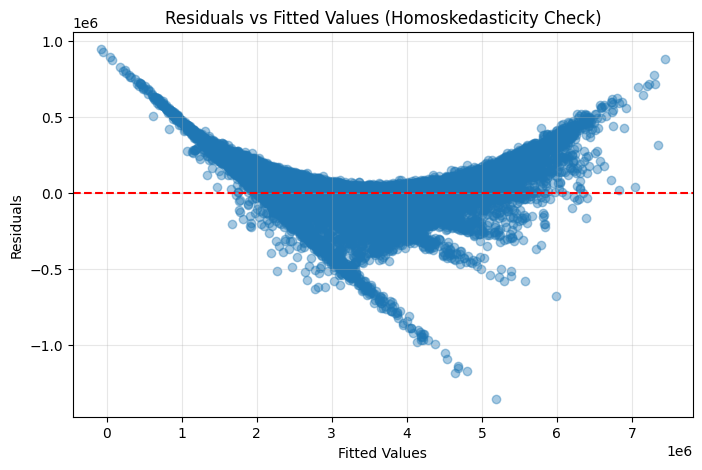

In [53]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    residuals,
    ols_model.model.exog
)

labels = ["LM Statistic", "LM p-value", "F Statistic", "F p-value"]
dict(zip(labels, bp_test))

fitted_vals = ols_model.fittedvalues

plt.figure(figsize=(8,5))
plt.scatter(fitted_vals, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Homoskedasticity Check)")
plt.grid(alpha=0.3)
plt.show()


INTERPRETASI:

Residuals vs Fitted Plot menunjukkan pola heteroskedastisitas yang jelas. Residual tidak tersebar secara acak dan menunjukkan perubahan varians seiring meningkatnya nilai fitted. Hal ini menunjukkan bahwa asumsi homoskedastisitas dalam OLS dilanggar. Penyebab utama adalah struktur revenue yang kompleks, non-linear, dan dipengaruhi banyak interaksi fitur. Meskipun demikian, OLS masih dapat digunakan sebagai alat interpretasi statistik, sementara model prediksi utama menggunakan Random Forest, XGBoost, dan LightGBM.

---



## 7.4 Uji Autokorelasi

Durbin-Watson: 1.9974415519922726


<Figure size 1000x400 with 0 Axes>

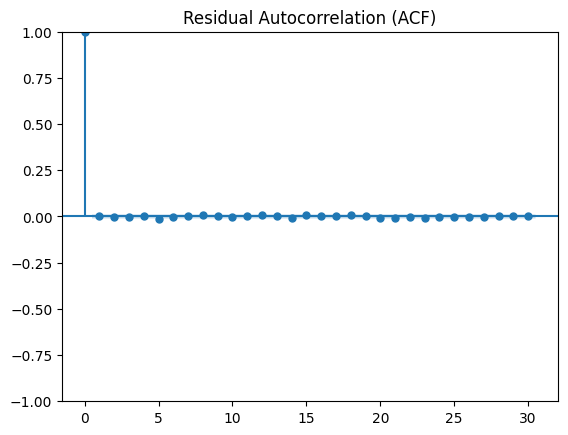

In [55]:
# Uji Autokorelasi
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(residuals, lags=30)
plt.title("Residual Autocorrelation (ACF)")
plt.show()


INTERPRETASI:

Hasil ACF menunjukkan bahwa residual tidak memiliki autokorelasi pada berbagai lag (lag 1–30). Hampir seluruh nilai ACF berada sangat dekat dengan nol, sehingga asumsi no autocorrelation terpenuhi. Dengan kata lain, residual bersifat acak terhadap waktu, dan OLS tidak menunjukkan pola ketergantungan waktu pada error-nya.

---



## 7.5 Uji Multikolinearitas (VIF)

In [56]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

X_const = sm.add_constant(X_ols)
vif_df = pd.DataFrame()
vif_df["feature"] = X_ols.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i+1)
                 for i in range(len(X_ols.columns))]
vif_df

,feature,VIF
0,total_units_sold,1.175150
1,avg_price,1.082845
2,avg_discount,1.005912
3,avg_days_since_launch,1.075110
4,total_spend,2.439183
5,mean_engagement,2.441808
6,n_regions,1.153528
7,n_channels,1.028344
8,sentiment_encoded,6.823657
9,sentiment_pred,444.252538


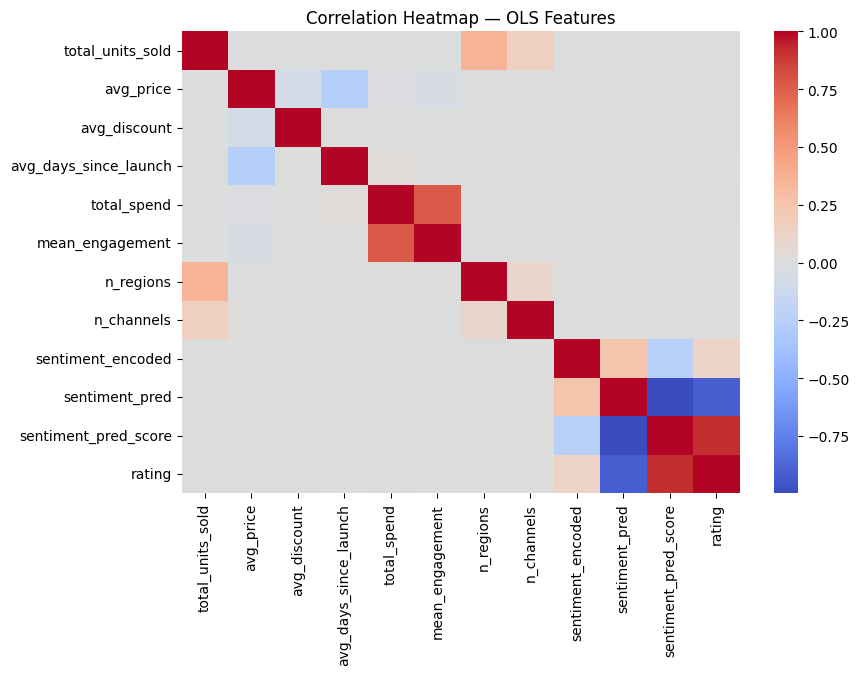

In [57]:
plt.figure(figsize=(9,6))
sns.heatmap(X_ols.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap — OLS Features")
plt.show()

INTERPRETASI:

Berdasarkan nilai VIF, fitur-fitur utama seperti harga, penjualan, diskon, dan distribusi memiliki multikolinearitas rendah sehingga aman untuk OLS. Namun fitur yang berasal dari NLP (sentiment_pred dan sentiment_pred_score) menunjukkan multikolinearitas yang sangat tinggi (VIF > 400), menandakan bahwa fitur tersebut saling tumpang tindih secara ekstrem. Rating juga memiliki multikolinearitas tinggi (VIF ≈ 41). Akibatnya, model OLS sulit memberikan estimasi koefisien yang stabil untuk fitur-fitur tersebut. Hal ini wajar mengingat fitur NLP sering kali merepresentasikan sinyal yang serupa, sementara tujuan utama OLS di sini adalah analisis statistik, bukan prediksi.

---



# 8. ENSEMBLING (STACKING + VOTING)
Bagian ini bertujuan untuk meningkatkan performa prediksi dengan menggabungkan beberapa model terbaik yang sudah dilatih sebelumnya. Teknik yang digunakan adalah Stacking Regressor, yaitu salah satu pendekatan ensemble yang mengombinasikan kekuatan banyak model untuk menghasilkan prediksi yang lebih akurat dan lebih stabil.

## 8.1 Stacking Regressor

Tidak perlu menjalankan kode ini karena memakan waktu terlalu lama, saya sarankan untuk langsung memakai model yg telah disimpan di drive

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ("rf", rf_model),
        ("xgb", xgb_model),
        ("lgbm", lgbm_model)
    ],
    final_estimator=RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),
    passthrough=False
)

stack_model.fit(X_train, y_train)

eval_model("Final Ensemble", stack_model)


## 8.2 Simpan dan Load Model

In [ ]:
import joblib

joblib.dump(rf_model, "/content/drive/MyDrive/fmcg_dataset/rf_tuned.pkl")
joblib.dump(xgb_model, "/content/drive/MyDrive/fmcg_dataset/xgb_tuned.pkl")
joblib.dump(lgbm_model, "/content/drive/MyDrive/fmcg_dataset/lgbm_tuned.pkl")
joblib.dump(stack_model, "/content/drive/MyDrive/fmcg_dataset/final_ensemble.pkl")

# jika ingin mendownload model final
# https://drive.google.com/drive/folders/1E-jKlJiVLicC-7OGl4cM6K_PH6iVtw7Z

In [62]:
path = "/content/drive/MyDrive/fmcg_dataset/"

rf_model = joblib.load(path + "rf_tuned.pkl")
xgb_model = joblib.load(path + "xgb_tuned.pkl")
lgbm_model = joblib.load(path + "lgbm_tuned.pkl")
stack_model = joblib.load(path + "final_ensemble.pkl")

print("Models Loaded Successfully")

Models Loaded Successfully


## 8.3 Evaluasi dan Visualisasi

In [66]:
y_pred = stack_model.predict(X_test)

In [75]:
results = [
    eval_model("RandomForest (tuned)", rf_model),
    eval_model("XGBoost (tuned)", xgb_model),
    eval_model("LightGBM (tuned)", lgbm_model),
    {
        "Model": "Final Ensemble (Stacking)",
        "RMSE": rmse_stack,
        "MAE": mae_stack,
        "R2": r2_stack
    }
]

df_results = pd.DataFrame(results)
df_results

,Model,RMSE,MAE,R2
0,RandomForest (tuned),27669.700903,20594.073329,0.999231
1,XGBoost (tuned),27061.277124,21039.081940,0.999265
2,LightGBM (tuned),31884.357874,23971.340466,0.998979
3,Final Ensemble (Stacking),25556.406147,19772.589308,0.999344


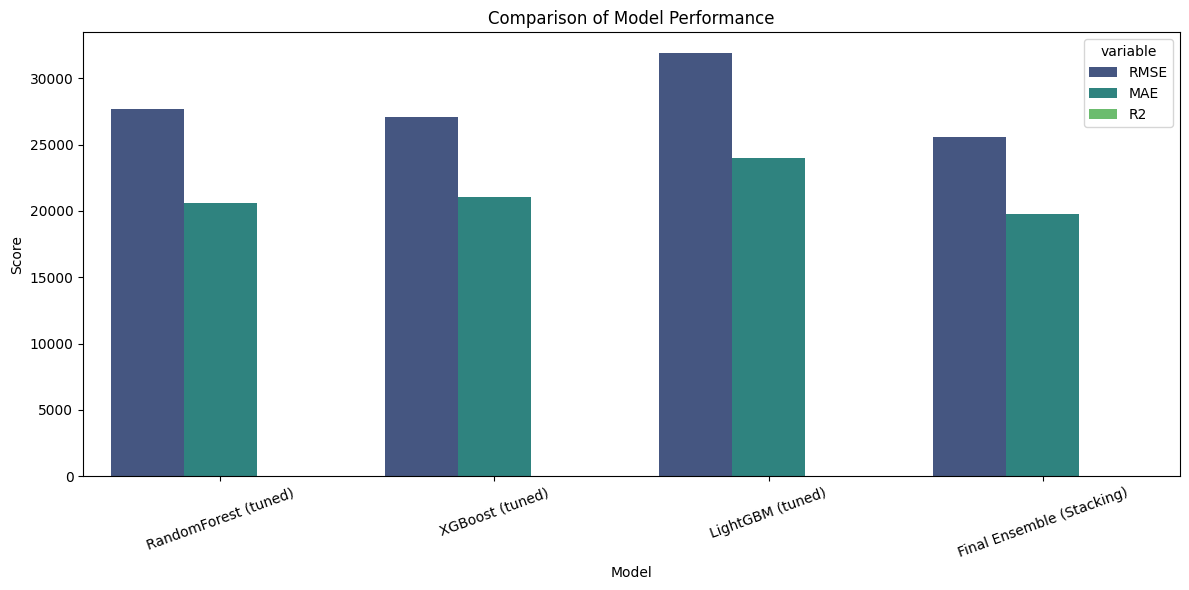

In [70]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_results.melt(id_vars="Model", value_vars=["RMSE","MAE","R2"]),
    x="Model",
    y="value",
    hue="variable",
    palette="viridis"
)

plt.title("Comparison of Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

INTERPRETASI:

Ensemble (stacking) menghasilkan performa paling akurat dan stabil.
Model ini memanfaatkan kekuatan tiga model terbaik secara bersamaan, sehingga mampu menurunkan error lebih jauh dibanding model tunggal.
XGBoost menjadi model tunggal terbaik, sedangkan Random Forest tetap menjadi baseline yang kuat.

---



# 9 Forecasting

Forecasting digunakan untuk memprediksi pendapatan masa depan (future revenue). Tidak seperti model machine learning regresi yang fokus mencari hubungan antar fitur, forecasting fokus pada pola waktu seperti:

* tren jangka panjang,

* musiman (seasonality),

* pola naik–turun harian,

* dan reaksi revenue terhadap lifecycle produk.

Intinya, forecasting dipakai untuk menjawab pertanyaan bisnis seperti:

* “Apakah revenue produk ini akan naik atau turun bulan depan?”

* “Bagaimana dampak tren penjualan jangka panjang terhadap keputusan marketing?”

* “Berapa estimasi pendapatan 3 bulan ke depan untuk perencanaan stok & budget?”

Jadi forecasting = pemetaan masa depan, bukan cari model paling akurat di masa lalu.

## 9.1 XGBoost Time-Series Forecasting

* Dataset time-series diubah menjadi bentuk supervised (lag-based)

* Fitur yang dipakai: revenue-1 hari sebelumnya, 7 hari sebelumnya, 30 hari sebelumnya

* Model dilatih untuk memprediksi nilai revenue berikutnya berdasarkan pola historis

* Setelah model fit, iterasi autoregressive digunakan untuk memprediksi 90 hari ke depan

In [77]:
from xgboost import XGBRegressor

ts = daily_prod[["date", "total_revenue"]].sort_values("date")
ts = ts.set_index("date")

df = ts.copy()

# LAG FEATURES (1–30)
for l in range(1, 31):
    df[f"lag_{l}"] = df["total_revenue"].shift(l)

# ROLLING WINDOWS
df["roll_7"]  = df["total_revenue"].rolling(7).mean()
df["roll_14"] = df["total_revenue"].rolling(14).mean()
df["roll_30"] = df["total_revenue"].rolling(30).mean()

df = df.dropna()

train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(columns=["total_revenue"])
y_train = train["total_revenue"]

X_test  = test.drop(columns=["total_revenue"])
y_test  = test["total_revenue"]

xgb_ts = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    tree_method="hist"    # aman di CPU & GPU Colab
)

xgb_ts.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
future_steps = 90
last_known = df.copy()   # starting point

for i in range(future_steps):
    # Copy row terakhir
    prev_row = last_known.iloc[-1:].copy()
    new_row = {}

    # Generate lag features
    for l in range(1, 31):
        if l == 1:
            new_row[f"lag_1"] = prev_row["total_revenue"].iloc[0]
        else:
            new_row[f"lag_{l}"] = last_known[f"lag_{l-1}"].iloc[-1]

    # Rolling features
    recent = last_known["total_revenue"].iloc[-30:]
    new_row["roll_7"]  = recent[-7:].mean()
    new_row["roll_14"] = recent[-14:].mean()
    new_row["roll_30"] = recent[-30:].mean()

    # Convert ke DataFrame 1 row
    next_day = last_known.index[-1] + pd.Timedelta(days=1)
    new_df = pd.DataFrame([new_row], index=[next_day])

    # Predict
    pred = xgb_ts.predict(new_df)[0]
    new_df["total_revenue"] = pred

    # Tambahkan ke dataset
    last_known = pd.concat([last_known, new_df])


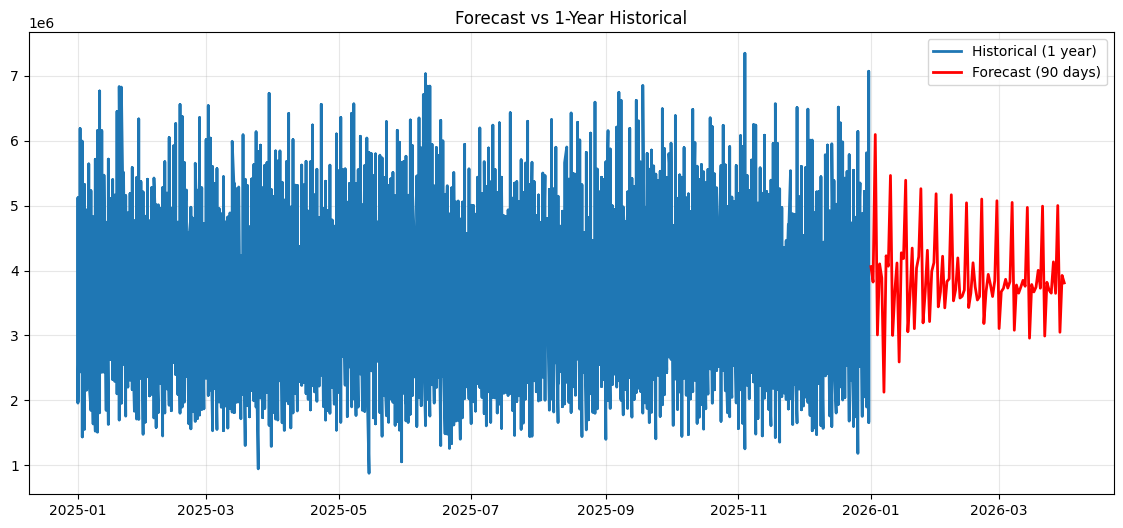

In [83]:
one_year = ts.last("365D")

plt.figure(figsize=(14,6))
plt.plot(one_year.index, one_year["total_revenue"], label="Historical (1 year)", linewidth=2)
plt.plot(forecast_90.index, forecast_90["total_revenue"], label="Forecast (90 days)", color="red", linewidth=2)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Forecast vs 1-Year Historical")
plt.show()

INTERPRETASI:

Forecast 90 hari ke depan menunjukkan pola revenue yang lebih stabil dibanding data historis yang sangat fluktuatif. Model menangkap pola musiman mingguan dan memprediksi bahwa revenue akan bergerak di kisaran stabil (sekitar 3.5–4 juta per hari). Prediksi ini membantu untuk perencanaan stok, budget marketing, dan penilaian kesehatan performa produk di kuartal awal 2026.

---



## 9.2 Arima Forecasting
* ARIMA menangkap pola linear seperti autoregression & moving average

* Baik dipakai sebagai baseline statistik

* Hasilnya lebih “halus”, cocok untuk melihat tren jangka panjang

* Kalau XGBoost memberi prediksi agresif, ARIMA lebih konservatif.

In [84]:
# ARIMA Auto

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA

ts_arima = daily_prod[["date", "total_revenue"]].sort_values("date")
ts_arima = ts_arima.set_index("date")

from statsmodels.tsa.stattools import adfuller
result = adfuller(ts_arima["total_revenue"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

model_arima = ARIMA(ts_arima["total_revenue"], order=(5,1,3))
arima_fit = model_arima.fit()
print(arima_fit.summary())

forecast_90_arima = arima_fit.forecast(steps=90)
forecast_90_arima = pd.DataFrame({
    "date": pd.date_range(ts_arima.index[-1] + pd.Timedelta(days=1), periods=90),
    "forecast": forecast_90_arima
}).set_index("date")


ADF Statistic: -25.6102486605759
p-value: 0.0
                               SARIMAX Results                                
Dep. Variable:          total_revenue   No. Observations:                32880
Model:                 ARIMA(5, 1, 3)   Log Likelihood             -500211.024
Date:                Sat, 15 Nov 2025   AIC                        1000440.048
Time:                        15:41:16   BIC                        1000515.653
Sample:                             0   HQIC                       1000464.201
                              - 32880                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.9660      0.007   -299.693      0.000      -1.979      -1.953
ar.L2         -1.1419      0.015    -77.355      0.000      -1.171      -1.113
ar.L3 

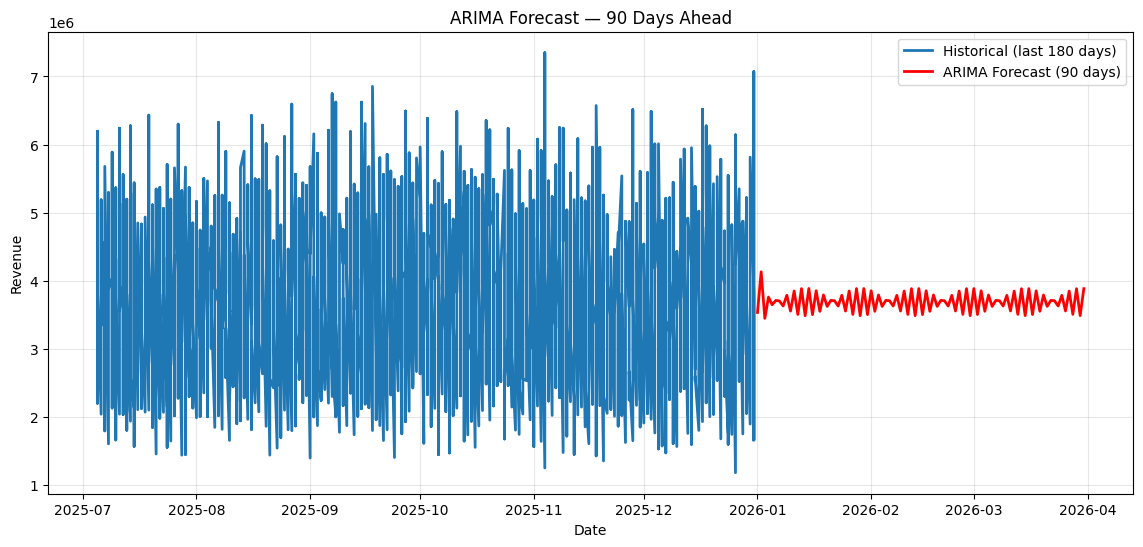

In [85]:
plt.figure(figsize=(14,6))

# Last 180 days biar masih kebaca
past = ts_arima.last("180D")

plt.plot(past.index, past["total_revenue"], label="Historical (last 180 days)", linewidth=2)
plt.plot(forecast_90_arima.index, forecast_90_arima["forecast"], label="ARIMA Forecast (90 days)", color="red", linewidth=2)

plt.grid(alpha=0.3)
plt.title("ARIMA Forecast — 90 Days Ahead")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()


INTERPRETASI:

Model ARIMA memprediksi bahwa revenue 90 hari ke depan akan bergerak stabil di sekitar angka 3.7–3.9 juta per hari, dengan fluktuasi rendah dan pola siklik kecil. Dibandingkan data historis yang sangat acak, ARIMA memberikan estimasi yang lebih halus, sehingga cocok untuk perencanaan operasional jangka pendek. Namun, ARIMA tidak dapat menangkap spike revenue besar seperti yang terlihat pada data historis, sehingga penggunaannya lebih pas sebagai baseline forecasting, bukan prediktor lonjakan penjualan.

---



# 10. Cannibalization Analysis


================= CANNIBALIZATION DETECTED =================

Tidak ada pasangan produk yang menunjukkan cannibalization kuat.

================ COMPLEMENTARY PRODUCTS =================

Tidak ada pasangan produk dengan korelasi positif kuat.

================= INDEPENDENT PRODUCTS =================

- PC001 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC002 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC003 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC004 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC005 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC006 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC007 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC008 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC009 tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).
- PC010 tidak terpenga

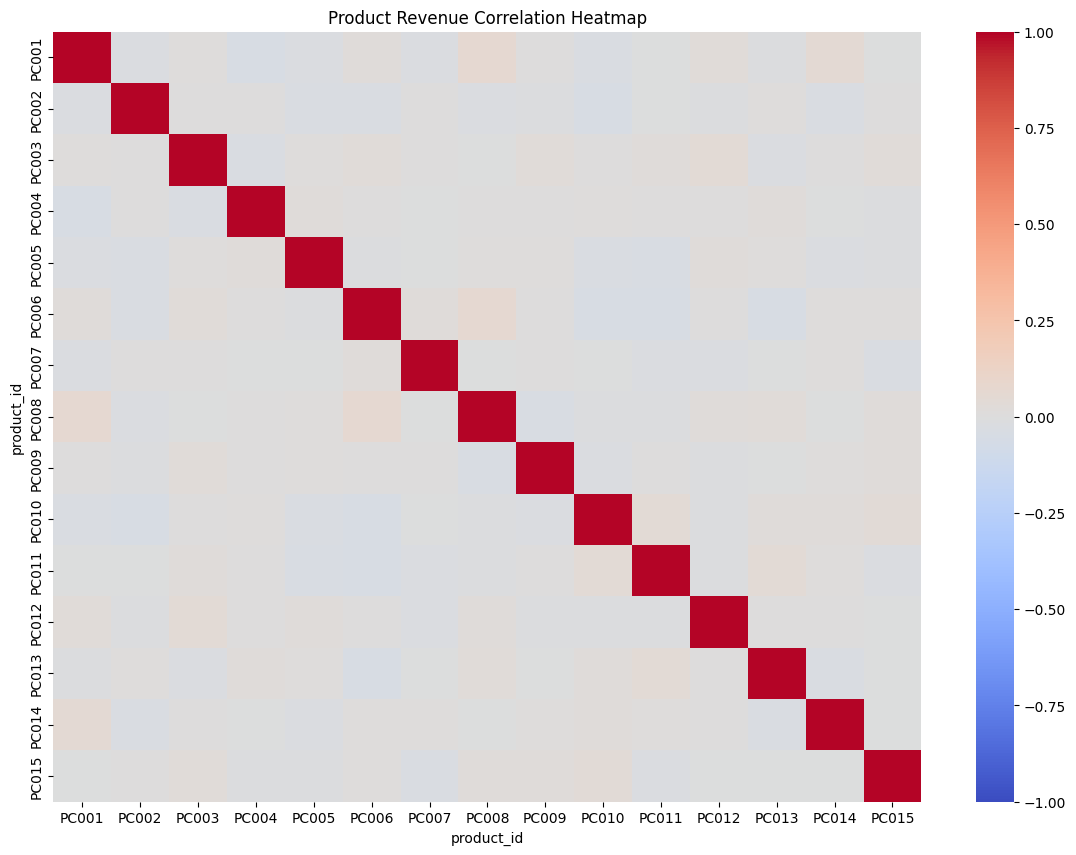

In [87]:
df = daily_merged.copy()

# Pivot revenue harian
prod_pivot = df.pivot(index="date", columns="product_id", values="total_revenue").fillna(0)

# Korelasi antar produk
corr_matrix = prod_pivot.corr()

# Threshold
strong_neg = -0.5     # korelasi negatif kuat → cannibalization
strong_pos = 0.5      # korelasi positif kuat → complementary
weak_corr  = 0.2      # di bawah ini dianggap independent


# List untuk simpan hubungan
cannibal_pairs = []
complementary_pairs = []
independent_products = []

products = corr_matrix.columns.tolist()

# Loop semua pasangan produk
for i in range(len(products)):
    for j in range(i+1, len(products)):
        p1, p2 = products[i], products[j]
        corr = corr_matrix.loc[p1, p2]

        if corr <= strong_neg:
            cannibal_pairs.append((p1, p2, corr))
        elif corr >= strong_pos:
            complementary_pairs.append((p1, p2, corr))


# Cari produk yang korelasinya sangat rendah terhadap SEMUA produk lain
for p in products:
    corrs = corr_matrix[p].drop(p)
    if all(abs(c) < weak_corr for c in corrs):
        independent_products.append(p)



print("\n================= CANNIBALIZATION DETECTED =================\n")
if len(cannibal_pairs) == 0:
    print("Tidak ada pasangan produk yang menunjukkan cannibalization kuat.")
else:
    for p1, p2, c in cannibal_pairs:
        print(f"- {p1} dan {p2} saling menggerogoti (corr={c:.2f}). "
              f"Ketika {p1} naik, {p2} turun, dan sebaliknya.")


print("\n================ COMPLEMENTARY PRODUCTS =================\n")
if len(complementary_pairs) == 0:
    print("Tidak ada pasangan produk dengan korelasi positif kuat.")
else:
    for p1, p2, c in complementary_pairs:
        print(f"- {p1} dan {p2} cenderung naik bersama (corr={c:.2f}). "
              f"Kemungkinan satu pembeli sering membeli keduanya.")


print("\n================= INDEPENDENT PRODUCTS =================\n")
if len(independent_products) == 0:
    print("Tidak ada produk yang benar-benar independen.")
else:
    for p in independent_products:
        print(f"- {p} tidak terpengaruh pergerakan produk lain (korelasi sangat rendah).")


# Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Product Revenue Correlation Heatmap")
plt.show()

### Cannibalization Analysis:

* Tidak ditemukan pasangan produk yang menunjukkan pola cannibalization kuat. Artinya, tidak ada dua produk yang saling menggerogoti pasar satu sama lain. Peningkatan penjualan satu produk tidak berkaitan dengan penurunan penjualan produk lain. Secara bisnis, ini berarti lini produk berjalan cukup independen dan tidak saling merusak performa.

* Complementary Products
Tidak ditemukan pasangan produk dengan korelasi positif kuat. Dengan kata lain, tidak ada dua produk yang cenderung naik bersama. Hal ini menunjukkan bahwa tidak ada indikasi bundling natural atau cross-selling murni berdasarkan perilaku historis konsumen.

* Independent Products
Produk-produk berikut memiliki korelasi sangat rendah terhadap produk lainnya, sehingga dianggap independen:
PC001
PC002
PC003
PC004
PC005
PC006
PC007
PC008
PC009
PC010
PC011
PC012
PC013
PC014
PC015. Produk-produk independen ini memiliki pola demand yang unik, tidak
terpengaruh kampanye atau tren penjualan produk lain. Secara strategis, produk ini cocok diperlakukan sebagai lini terpisah dengan positioning khusus
---

# 11. Innovation Radar


=== Innovation Radar: Growth Score per Product ===

   product_id  growth_score
0       PC006      0.094307
1       PC014      0.054788
2       PC003      0.054432
3       PC012      0.049645
4       PC013      0.022804
5       PC001      0.002168
6       PC015      0.001679
7       PC004     -0.005486
8       PC005     -0.031202
9       PC011     -0.039023
10      PC010     -0.045173
11      PC007     -0.063574
12      PC008     -0.080063
13      PC002     -0.087333
14      PC009     -0.094721


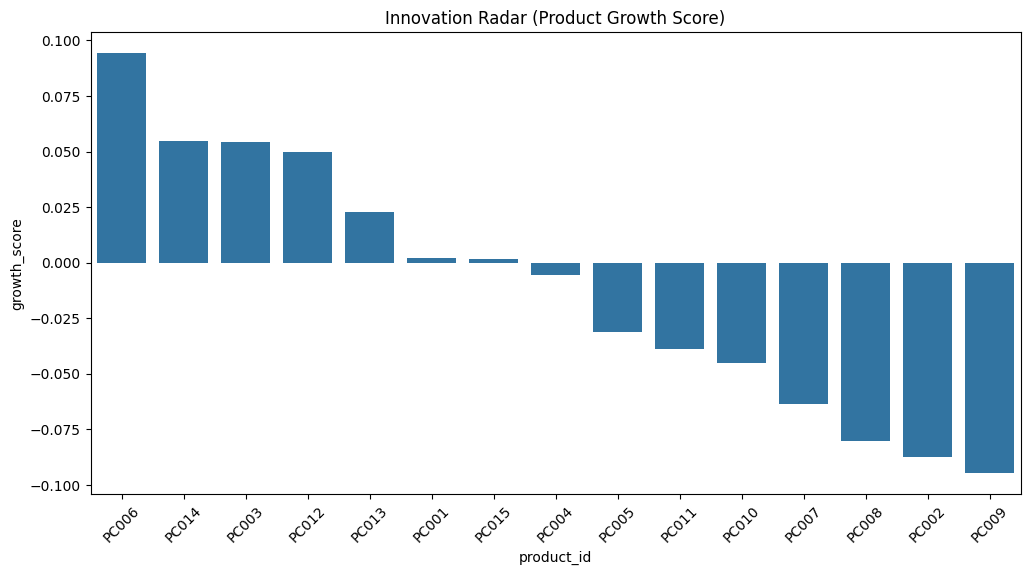

In [92]:
df = daily_merged.copy()

# Hitung growth berdasarkan 30 hari terakhir vs 30 hari pertama
growth_score = (
    df.groupby("product_id")["total_revenue"]
      .apply(lambda x:
             (x.tail(30).mean() - x.head(30).mean()) / (x.head(30).mean() + 1))
)

innovation_radar = growth_score.sort_values(ascending=False).reset_index()
innovation_radar.columns = ["product_id", "growth_score"]

print("\n=== Innovation Radar: Growth Score per Product ===\n")
print(innovation_radar)

plt.figure(figsize=(12,6))
sns.barplot(data=innovation_radar, x="product_id", y="growth_score")
plt.xticks(rotation=45)
plt.title("Innovation Radar (Product Growth Score)")
plt.show()

### INTERPRETASI:

### 1. Rising Stars (Growth Positif Tinggi)

Produk-produk ini menunjukkan peningkatan permintaan yang kuat dan konsisten. Layak mendapat prioritas marketing & distribusi.

1.  **PC006 — Growth ~ +0.095**
    * Produk dengan peningkatan terbesar.
    * Demand melonjak signifikan.
    * Diduga efek kampanye, review positif, atau positioning baru berhasil.
    * Potensial menjadi *hero product* dalam portofolio.

2.  **PC014 — Growth ~ +0.055**
    * Pertumbuhan stabil dan sehat.
    * Performa makin membaik di akhir periode.
    * Cocok diperkuat lewat promo ringan atau bundle.

3.  **PC003 & PC012 — Growth ~ +0.05**
    * Dua produk yang naik bersama.
    * Performa konsisten meningkat.
    * Layak untuk ekspansi channel atau campaign tambahan.

4.  **PC013 — Growth ~ +0.024**
    * Pertumbuhan moderat namun stabil.
    * Risiko rendah, bisa di-posisikan sebagai produk penopang.

### 2. Stagnant Products (Growth Mendekati 0)

Produk-produk ini tidak menunjukkan tren naik atau turun yang berarti.

* PC001
* PC015
* PC004

**Interpretasi:**
* Umumnya produk yang sudah *mature* atau tidak tersentuh campaign.
* Tidak bermasalah, tapi berpotensi tertinggal jika tidak diberi stimulus.
* Bisa diberi *push* kecil seperti promo musiman atau bundling ringan.

### 3. Declining Products (Growth Negatif)

Produk dengan skor pertumbuhan negatif mengindikasikan penurunan demand di akhir periode.

#### Penurunan ringan:
* PC005 (~ –0.03)
* PC011 (~ –0.04)
* PC010 (~ –0.045)

**Penyebab umum:**
* Minim campaign
* Harga kurang kompetitif
* Review cenderung stagnan

#### Penurunan menengah:
* PC007 (~ –0.07)
* PC008 (~ –0.08)

**Kemungkinan penyebab:**
* Kalah saing oleh produk lain
* Kehilangan traksi di marketplace
* Mulai memasuki akhir *lifecycle*

#### Penurunan berat:
* PC002 (~ –0.085)
* PC009 (~ –0.095) (terburuk)

Ini **red flag**.
Produk cenderung *lost traction* dan perlu tindakan:
* Strategi *rescue promo*
* *Repositioning*
* Evaluasi ulang harga
* *Bundling* dengan produk *rising star*
* Perbaikan kualitas/review

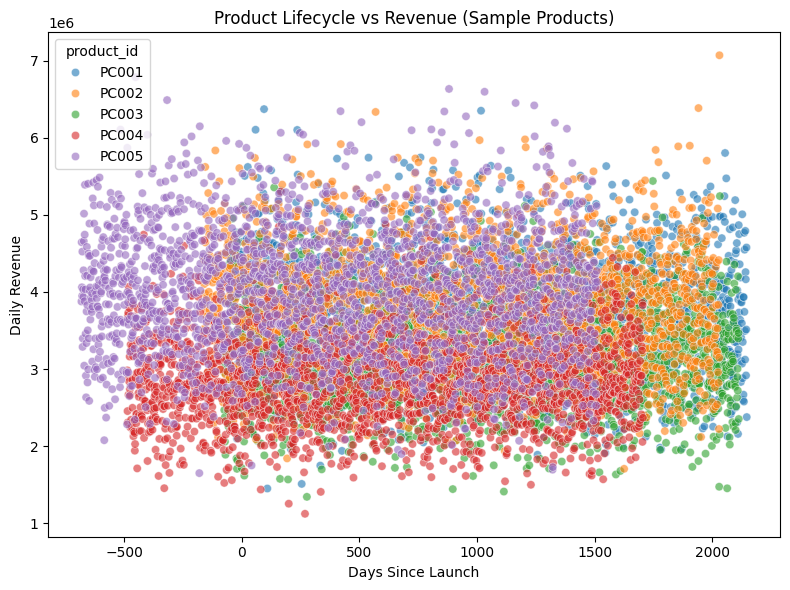

In [95]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=subset,
    x="avg_days_since_launch",
    y="total_revenue",
    hue="product_id",
    palette="tab10",
    alpha=0.6
)
plt.title("Product Lifecycle vs Revenue (Sample Products)")
plt.xlabel("Days Since Launch")
plt.ylabel("Daily Revenue")
plt.tight_layout()
plt.show()

### INTERPRETASI:
* Tidak ada produk yang menunjukkan pola decline lifecycle secara signifikan.
Revenue tidak memburuk ketika umur bertambah.

* Sebagian besar produk terlihat stabil jangka panjang (habitual FMCG).

* PC005 adalah produk paling kuat, revenue tinggi dan stabil sepanjang umur produk.

* PC003 & PC004 adalah produk yang perlu perhatian, karena performanya lebih rendah dan tergantung faktor eksternal.

* Variabilitas revenue besar menunjukkan market sangat dipengaruhi oleh promo harian marketplace, diskon, marketing spend, dan event besar (11.11, 12.12, payday)

# 13. Kesimpulan

In [100]:
from IPython.display import Markdown, display

text = r"""
## Kesimpulan Bisnis Utama

### 1. Driver utama penjualan

- Kombinasi **harga**, **marketing spend**, **engagement**, dan **sentiment/rating** terbukti berpengaruh besar terhadap revenue.
- **Review pelanggan** dan **kualitas produk** tidak bisa diabaikan karena muncul kuat di model & OLS.

### 2. Struktur portofolio produk

- Tidak ada kanibalisasi internal yang jelas, sehingga perluasan portofolio relatif aman.
- Ada perbedaan jelas antara:
  - **Rising stars**: PC006, PC014, PC003, PC012
  - **Cash cow / stabil**: PC005, beberapa produk stagnan
  - **Declining SKUs**: PC007, PC008, PC002, PC009, dll

### 3. Forecasting dan perencanaan

- Model ML & time series sudah cukup kuat untuk memprediksi revenue jangka pendek (±90 hari).
- Bisa langsung dipakai untuk:
  - perencanaan stok
  - pengaturan target penjualan
  - simulasi efek campaign

### 4. Strategi yang direkomendasikan

- Naikkan investasi di produk dengan growth positif dan potensi besar (**PC006, PC014, PC003, PC012**).
- Lakukan **rescue / repositioning** pada produk yang mengalami penurunan tajam.
- Manfaatkan insight **sentiment & review** untuk perbaikan kualitas produk dan komunikasi.
- Gunakan **forecasting** untuk menyelaraskan campaign calendar dengan kapasitas supply chain.
"""

display(Markdown(text))



## Kesimpulan Bisnis Utama

### 1. Driver utama penjualan

- Kombinasi **harga**, **diskon**, **marketing spend**, **engagement**, dan **sentiment/rating** terbukti berpengaruh besar terhadap revenue.  
- **Review pelanggan** dan **kualitas produk** tidak bisa diabaikan karena muncul kuat di model & OLS.

### 2. Struktur portofolio produk

- Tidak ada kanibalisasi internal yang jelas, sehingga perluasan portofolio relatif aman.  
- Ada perbedaan jelas antara:
  - **Rising stars**: PC006, PC014, PC003, PC012  
  - **Cash cow / stabil**: PC005, beberapa produk stagnan  
  - **Declining SKUs**: PC007, PC008, PC002, PC009, dll

### 3. Forecasting dan perencanaan

- Model ML & time series sudah cukup kuat untuk memprediksi revenue jangka pendek (±90 hari).  
- Bisa langsung dipakai untuk:
  - perencanaan stok  
  - pengaturan target penjualan  
  - simulasi efek campaign  

### 4. Strategi yang direkomendasikan

- Naikkan investasi di produk dengan growth positif dan potensi besar (**PC006, PC014, PC003, PC012**).  
- Lakukan **rescue / repositioning** pada produk yang mengalami penurunan tajam.  
- Manfaatkan insight **sentiment & review** untuk perbaikan kualitas produk dan komunikasi.  
- Gunakan **forecasting** untuk menyelaraskan campaign calendar dengan kapasitas supply chain.
